## Notebook 5: AC Adaptation

In [1]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [2]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [3]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: genova Genova
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/gviGenova/gvi_Genova.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/CoolingEff/outer_2_wbgt_max.csv


**Loading from before**

In [4]:
from pathlib import Path
import json, numpy as np, geopandas as gpd, rasterio as rio

tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"

age_npz = INT / f"age_on_ref_{SLUG}.npz"
if not age_npz.exists():
    age_npz = INT / "age_on_ref.npz"

pop_npz = INT / f"pop_on_ref_{SLUG}.npz"
if not pop_npz.exists():
    pop_npz = INT / "pop_on_ref.npz"

AUX_NPZ = INT / f"{SLUG}_veg_aux_arrays.npz"
muni_tif_new = OUT / f"{SLUG}_muni_on_ref.tif"
muni_tif_legacy = OUT / "muni_on_ref.tif"

# Template/meta + mask 
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

# Age / population rasters on ref grid 
agez = np.load(age_npz)
age_on_ref = {
    "<15":   agez["lt15"].astype("float32"),
    "15-64": agez["a15_64"].astype("float32"),
    "65+":   agez["g65"].astype("float32"),
}
pop_on_ref = np.load(pop_npz)["pop"].astype("float32")

# FUA vector 
if not fua_gp.exists():
    raise FileNotFoundError(f"Missing FUA GeoPackage: {fua_gp} — re-run Notebook 2 for {CITY}.")
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

# Footprint / analysis masks 
ref_data = np.where(CITY_MASK, 0.0, np.nan).astype("float32")  # same shape as ref grid
HAZ_MASK = np.isfinite(ref_data)

# Not strictly required for AC, but useful for later plots/joins
if AUX_NPZ.exists():
    aux = np.load(AUX_NPZ)
    muni_on_ref = aux.get("muni_on_ref", None)
    lcz_on_ref  = aux.get("lcz_on_ref",  None)
    gvi_on_ref  = aux.get("gvi_on_ref",  None)
    dGVI_points = aux.get("dGVI_points", None)
    dT_month_ref= aux.get("dT_month_ref", None)

# If AUX bundle missing, try muni label from GeoTIFF saved in NB5
if 'muni_on_ref' not in globals() or muni_on_ref is None:
    if muni_tif_new.exists() or muni_tif_legacy.exists():
        with rio.open(muni_tif_new if muni_tif_new.exists() else muni_tif_legacy) as src:
            muni_on_ref = src.read(1).astype("int32")  # 0 = outside
    else:
        muni_on_ref = None

print(f"Ref grid: {(HGT, WDT)} | CRS: {ref_meta['crs']}")
print("CITY_MASK true pixels:", int(CITY_MASK.sum()))
print("Pop sum on ref:", float(np.nansum(pop_on_ref)))
print("AUX loaded:", AUX_NPZ.exists(), "| muni_on_ref set:", muni_on_ref is not None)

Ref grid: (251, 251) | CRS: EPSG:3035
CITY_MASK true pixels: 26584
Pop sum on ref: 576549.75
AUX loaded: True | muni_on_ref set: True


In [5]:
import geopandas as gpd, rasterio as rio, pandas as pd, numpy as np

# paths
gpkg_path = OUT / f"{SLUG}_regions.gpkg"
tif_path  = OUT / f"{SLUG}_muni_on_ref.tif"
lut_path  = OUT / f"{SLUG}_muni_lut.csv"

# loading vectors
regions = gpd.read_file(gpkg_path, layer="regions").to_crs("EPSG:4326")
muni    = gpd.read_file(gpkg_path, layer="muni").to_crs("EPSG:4326")
lut     = pd.read_csv(lut_path)

# loading label grid (aligned to T2M ref grid)
with rio.open(tif_path) as src:
    assert src.crs == ref_meta["crs"] and src.transform == ref_meta["transform"], "Grid mismatch."
    muni_on_ref = src.read(1).astype("int32")

print("Loaded regions:", len(regions), "polygons; muni_on_ref shape:", muni_on_ref.shape)

valid_ids = np.unique(muni_on_ref[muni_on_ref > 0])
print("Unique muni IDs (excluding 0):", len(valid_ids))

Loaded regions: 10 polygons; muni_on_ref shape: (251, 251)
Unique muni IDs (excluding 0): 9


In [6]:
from climada.hazard import Hazard
from climada.entity import Exposures

from pathlib import Path

def _pick_existing(cands, what):
    """Return the first existing path in cands, or raise a clear error."""
    for p in cands:
        if p and Path(p).exists():
            return Path(p)
    tried = "\n".join(str(Path(p)) for p in cands if p)
    raise FileNotFoundError(f"Missing {what}. Tried:\n{tried}")

# loading hazard and exposure
haz_candidates = [
    paths.get("hazard_h5"),
    INT / f"hazard_T2M_daily_{SLUG}.h5",
    OUT / f"hazard_T2M_daily_{SLUG}.h5",
    INT / f"hazard_HEAT_{SLUG}.h5",
    INT / f"{SLUG}_hazard_HEAT.h5",
    INT / "hazard_HEAT.h5",
    OUT / f"hazard_HEAT_{SLUG}.h5",
    OUT / f"{SLUG}_hazard_HEAT.h5",
]

exp_candidates = [
    paths.get("exposure_h5"),
    INT / f"exposure_people_{SLUG}.h5",
    INT / f"{SLUG}_exposure_people.h5",
    INT / "exposure_people.h5",
    OUT / f"exposure_people_{SLUG}.h5",
    OUT / f"{SLUG}_exposure_people.h5",
]

haz_path = _pick_existing(haz_candidates, "hazard .h5")
exp_path = _pick_existing(exp_candidates, "exposure .h5")

# Read via CLIMADA
try:
    H = Hazard.from_hdf5(haz_path)
except Exception:
    H = Hazard(); H.read_hdf5(haz_path)

try:
    exp = Exposures.from_hdf5(exp_path)
except Exception:
    exp = Exposures(); exp.read_hdf5(exp_path)

import numpy as np

n_ev = H.intensity.shape[0]

# hazard type/units
if not getattr(H, "haz_type", None):
    H.haz_type = "T2M"                      # daily mean temperature
if not getattr(H, "units", None):
    H.units = "degC (daily mean)"

# event ids / dates: keep if present, otherwise try to reconstruct from CSV
if not hasattr(H, "event_id") or len(getattr(H, "event_id", [])) != n_ev:
    try:
        import pandas as pd
        ev = pd.read_csv(INT / f"hazard_T2M_daily_events_{SLUG}.csv")
        if len(ev) == n_ev:
            H.event_id = ev["event_id"].to_numpy(int)
        else:
            H.event_id = np.arange(n_ev, dtype=int)
    except Exception:
        H.event_id = np.arange(n_ev, dtype=int)

if not hasattr(H, "date") or len(getattr(H, "date", [])) != n_ev:
    try:
        import pandas as pd
        ev = pd.read_csv(INT / f"hazard_T2M_daily_events_{SLUG}.csv",
                         parse_dates=["date"])
        if len(ev) == n_ev:
            H.date = ev["date"].to_numpy("datetime64[ns]")
    except Exception:
        pass

# frequency: each event is one day
# we later sum explicitly over days
if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != n_ev:
    H.frequency = np.ones(n_ev, dtype=float)
if not getattr(H, "frequency_unit", None):
    H.frequency_unit = "1/day"

# event_name 
if not hasattr(H, "event_name") or len(getattr(H, "event_name", [])) != n_ev:
    try:
        H.event_name = np.array(
            [f"T2M_{str(np.datetime_as_string(d, unit='D'))}" for d in H.date],
            dtype=object
        )
    except Exception:
        H.event_name = np.array([f"T2M_{i:06d}" for i in range(n_ev)],
                                dtype=object)

# strict grid check unchanged
n_cells = H.intensity.shape[-1]
assert n_cells == HGT * WDT, (
    f"[{SLUG}] grid mismatch: hazard cells={n_cells} vs ref={HGT*WDT}. "
    "Rebuild hazard on this ref grid."
)

In [7]:
# age-specific impact functions "frozen" in NB4 
import json, numpy as np
from pathlib import Path

def _pick_existing(cands, what):
    for p in cands:
        if p and Path(p).exists():
            return Path(p)
    tried = "\n".join(str(Path(p)) for p in cands if p)
    raise FileNotFoundError(f"Missing {what}. Tried:\n{tried}")

froze_candidates = [
    paths.get("if_freeze_json") if "paths" in globals() else None,
    Path(INT) / f"if_curves_frozen_{SLUG}.json",  # preferred
    Path(INT) / "if_curves_frozen.json",         
    Path(OUT) / f"if_curves_frozen_{SLUG}.json", 
]
froze_path = _pick_existing(froze_candidates, "frozen impact-function JSON")

with open(froze_path, "r") as fh:
    IF_FREEZE = json.load(fh)

class _IF:
    def __init__(self, intensity, mdd, name=None, fid=None):
        self.intensity = np.asarray(intensity, float)
        self.mdd       = np.asarray(mdd, float)
        self.name      = name
        self.id        = fid

required = {"intensity", "mdd"}
for k, v in IF_FREEZE.items():
    missing = required - v.keys()
    if missing:
        raise ValueError(f"IF '{k}' missing fields: {missing}")

age_ifs = {
    k: _IF(v["intensity"], v["mdd"], name=v.get("name"), fid=v.get("id"))
    for k, v in IF_FREEZE.items()
}
print("Loaded frozen IFs:",
      {k: (age_ifs[k].name, len(age_ifs[k].intensity)) for k in age_ifs})

Loaded frozen IFs: {'<15': ('<15', 81), '15-64': ('15–64', 81), '65+': ('65+', 81)}


In [8]:
# age rasters on the reference grid (saved in NB3) 
import numpy as np
from pathlib import Path

_age_tagged = INT / f"age_on_ref_{SLUG}.npz"
age_npz = _age_tagged if _age_tagged.exists() else (INT / "age_on_ref.npz")

agez = np.load(age_npz)
age_on_ref = {
    "<15":   agez["lt15"].astype("float32"),
    "15-64": agez["a15_64"].astype("float32"),
    "65+":   agez["g65"].astype("float32"),
}

In [9]:
# pick which scenario we want for efficacy (cf YAML config file)
EFF_SCENARIO = os.environ.get("EFF_SCENARIO", "high")

scenarios = cfg.get("efficacy_scenarios", {}) or {}

if EFF_SCENARIO in scenarios:
    EFF_BUCKETS = {k: float(v) for k, v in scenarios[EFF_SCENARIO].items()}
    # keep a default too 
    EFF_DEFAULT = float(cfg.get("efficacy", {}).get("default", 0.30))
else:
    # fallback to the existing single-map behavior
    eff_map = cfg.get("efficacy", {}) or {}
    EFF_DEFAULT = float(eff_map.get("default", 0.30))
    EFF_BUCKETS = {k: float(v) for k, v in eff_map.items() if k != "default"}

# ensure all age buckets exist (so later code never crashes)
for k in ["<15", "15-64", "65+"]:
    EFF_BUCKETS.setdefault(k, EFF_DEFAULT)

print("EFF_SCENARIO:", EFF_SCENARIO)
print("EFF_BUCKETS:", EFF_BUCKETS, "| default:", EFF_DEFAULT)

EFF_SCENARIO: high
EFF_BUCKETS: {'<15': 0.3, '15-64': 0.4, '65+': 0.55} | default: 0.3


## Current AC Penetration at the CAP Level

**Loading data : income and AC penetration**

No pixel netCDF anymore, NUTS csv!

In [10]:
import pandas as pd

def load_ac_city_by_year(cfg, P):
    """
    Returns dict like {2030: ..., 2040: ..., 2050: ...} using cfg['ac'].
    Works for any city as long as YAML is filled (nuts_id, years, columns, etc.).
    """
    ac_cfg = cfg["ac"]

    # file path (absolute via P)
    f = P(ac_cfg["penetration_file"])
    df = pd.read_csv(f)

    # Column mapping (so CSV can change without code changes)
    cols = ac_cfg.get("nuts_columns", {})
    col_id   = cols.get("id", "NUTS_ID")
    col_scen = cols.get("scenario", "Scenario")
    col_year = cols.get("year", "year")
    col_val  = cols.get("value", "value")

    nuts_id = ac_cfg["nuts_id"]

    # Scenario label in the CSV is "SSP2" 
    ssp = ac_cfg.get("ssp", 2)
    scenario = f"SSP{ssp}" if isinstance(ssp, (int, float)) or str(ssp).isdigit() else str(ssp)

    years = [int(y) for y in ac_cfg.get("years", [2030, 2040, 2050])]

    sub = df[(df[col_id] == nuts_id) & (df[col_scen] == scenario)].copy()
    if sub.empty:
        raise ValueError(f"No AC rows for {col_id}={nuts_id} and {col_scen}={scenario} in {f}")

    sub[col_year] = sub[col_year].astype(int)
    sub[col_val]  = sub[col_val].astype(float)

    ac_city_by_year = {}
    for y in years:
        hit = sub.loc[sub[col_year] == y, col_val]
        if hit.empty:
            raise ValueError(f"Missing year {y} for NUTS_ID={nuts_id}, Scenario={scenario}")
        ac_city_by_year[y] = float(hit.iloc[0])

    return ac_city_by_year

# usage
ac_city_by_year = load_ac_city_by_year(cfg, P)
YEARS_AC = sorted(ac_city_by_year.keys()) 
year_to_index = {y: i for i, y in enumerate(YEARS_AC)}

print("AC targets:", ac_city_by_year)
print("YEARS_AC:", YEARS_AC)

AC targets: {2030: 0.427151560783386, 2040: 0.427151560783386, 2050: 0.470641046762466}
YEARS_AC: [2030, 2040, 2050]


In [11]:
for y in YEARS_AC:
    print(y, ac_city_by_year[y])

2030 0.427151560783386
2040 0.427151560783386
2050 0.470641046762466


In [12]:
import pandas as pd, json

# csv file
ac_targets_csv = INT / f"ac_city_targets_{SLUG}.csv"
pd.DataFrame({
    "year": YEARS_AC,
    "ac_share": [float(ac_city_by_year[y]) for y in YEARS_AC],
}).to_csv(ac_targets_csv, index=False)

# metadata 
ac_cfg = cfg.get("ac", {})
cols = ac_cfg.get("nuts_columns", {})
scenario = f"SSP{ac_cfg.get('ssp', 2)}"
ac_targets_meta = {
    "nuts_id": ac_cfg.get("nuts_id", None),
    "scenario": scenario,
    "penetration_file": str(P(ac_cfg.get("penetration_file", ""))),
    "columns": {
        "id": cols.get("id", "NUTS_ID"),
        "scenario": cols.get("scenario", "Scenario"),
        "year": cols.get("year", "year"),
        "value": cols.get("value", "value"),
    },
}
with open(INT / f"ac_city_targets_meta_{SLUG}.json", "w") as f:
    json.dump(ac_targets_meta, f, indent=2)

print("✓ Wrote:", ac_targets_csv)

✓ Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ac_city_targets_genova.csv


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Under the scenario SSP2, (year), for the (city) pixel, the AC penetration share is of (...)
</blockquote>

Is there a better way to find the right pixel? I found the same one whatever the method...

> **Explanation of the following steps:**
> - We only know the Rome AC penetration share
> - We have income data at the CAP level
    > - We want a map across CAP where:
    > - Higher AC in richer CAPS and lower in poorer caps
    > - stays in plausible bounds
    > - averages back to 0.724 when we weight by ppl 

**Income Dataset**

In [13]:
import re
from pathlib import Path

files = cfg.get("files", {})
rel = files["income_csv"]                         
rel = re.sub(r'(^|/)[Ii]ncome/', r'\1income/', rel)  

income_csv = P(rel)                              
assert Path(income_csv).exists(), f"Missing income CSV: {income_csv}"
print("Income CSV →", income_csv)

Income CSV → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/income/Redditi_e_principali_variabili_IRPEF_su_base_subcom.csv


In [14]:
# normalising a CAP to a 5-digit string with 00 before or na if missing or invalid
def to_cap5(s):
    s = "" if pd.isna(s) else str(s)
    s = re.sub(r"\D","", s)
    return np.nan if not s else s.zfill(5)[-5:]

def _norm(s):
    return str(s).upper()

In [15]:
# columns for the Italian IRPEF file (same for Rome/Genova) 
COL_CITY   = "Denominazione Comune"
COL_CAP    = "CAP"
COL_TAXP   = "Numero contribuenti"
COL_TOTINC = "Reddito complessivo - Ammontare in euro"

In [16]:
# aliases from YAML 
aliases = [_norm(cfg.get("city_name", SLUG))]
aliases += [_norm(a) for a in cfg.get("cooling_city_aliases", [])]
aliases = list(dict.fromkeys(aliases))  

In [17]:
# load and city-filter
df = pd.read_csv(income_csv, sep=None, engine="python")
city_col = df[COL_CITY].astype(str).map(_norm)
mask = pd.Series(False, index=df.index)
for a in aliases:
    mask |= city_col.str.contains(a, na=False)

inc_city = df[mask].copy()

In [18]:
import re

# clean and compute 
inc_city[COL_TAXP]   = pd.to_numeric(inc_city[COL_TAXP],   errors="coerce")
inc_city[COL_TOTINC] = pd.to_numeric(inc_city[COL_TOTINC], errors="coerce")
inc_city["cap5"]     = inc_city[COL_CAP].map(to_cap5)

inc_city = inc_city.dropna(subset=["cap5", COL_TAXP, COL_TOTINC])
inc_city = inc_city[inc_city[COL_TAXP] > 0].copy()

inc_city["inc_mean"] = inc_city[COL_TOTINC] / inc_city[COL_TAXP]
lo, hi = inc_city["inc_mean"].quantile([0.01, 0.99])
inc_city["inc_w"] = inc_city["inc_mean"].clip(lo, hi)

print(f"[{SLUG}] CAP rows: {len(inc_city)} | unique CAP: {inc_city['cap5'].nunique()}")
print(f"[{SLUG}] Taxpayers total: {int(inc_city[COL_TAXP].sum())}")
city_mean = inc_city[COL_TOTINC].sum() / inc_city[COL_TAXP].sum()
print(f"[{SLUG}] City per-taxpayer mean (EUR): {city_mean:,.0f}")

[genova] CAP rows: 43 | unique CAP: 43
[genova] Taxpayers total: 436825
[genova] City per-taxpayer mean (EUR): 27,352


**CAP polygons to CLIMADA grid**

In [19]:
files = cfg.get("files", {})
p_cap_shp = P(files.get("cap_shp", "CAPZONE/CAPZONE.shp"))
assert p_cap_shp.exists(), f"Missing CAP shapefile: {p_cap_shp}"

In [20]:
# CAP polygons to CLIMADA grid labels
import numpy as np
import geopandas as gpd
from shapely import set_precision
from rasterio.features import rasterize

def pick_col(cols, *cands):
    low = {c.lower(): c for c in cols}
    for cand in cands:
        for k, v in low.items():
            if cand.lower() in k:
                return v
    raise KeyError(f"None of {cands} found in columns: {list(cols)}")

# loading CAP shapes
cap = gpd.read_file(p_cap_shp)
cap = cap.set_crs("EPSG:4326", allow_override=True) if cap.crs is None else cap.to_crs("EPSG:4326")

cap_col = pick_col(
    cap.columns,
    "cap", "CAP", "codice", "cod_cap", "cap_5", "cap5", "zip", "postal", "postcode"
)
cap["cap5"] = cap[cap_col].map(to_cap5)
cap = cap[cap["cap5"].notna()].copy()

# fix geometries and precision
cap = cap.set_geometry(cap.geometry.buffer(0))
cap = cap[~cap.geometry.is_empty]
cap = cap.set_geometry(set_precision(cap.geometry, grid_size=1e-9))

cap_4326 = (cap[["cap5","geometry"]]
            .dissolve(by="cap5", as_index=False))

# clipping to FUA 
fua_4326 = fua.to_crs("EPSG:4326")[["geometry"]]
cap_4326 = gpd.overlay(cap_4326, fua_4326, how="intersection")
cap_4326 = cap_4326[~cap_4326.geometry.is_empty].reset_index(drop=True)

# stable IDs + project to ref grid CRS 
cap_4326["cap_id"] = np.arange(1, len(cap_4326)+1, dtype=int)
cap_ref = cap_4326.to_crs(ref_meta["crs"])

# rasterize to the ref grid 
shapes = [(geom, int(cid)) for geom, cid in zip(cap_ref.geometry, cap_ref["cap_id"])]
cap_on_ref = rasterize(
    shapes=shapes,
    out_shape=ref_data.shape,
    transform=ref_meta["transform"],
    fill=0, dtype="int32",
    all_touched=False
)

# checks 
haz_mask = np.isfinite(ref_data)
u_ids = np.unique(cap_on_ref[haz_mask])
print(f"[{SLUG}] CAP pixels in hazard: {int(((cap_on_ref>0)&haz_mask).sum()):,}")
print(f"[{SLUG}] Unique CAP IDs on grid: {u_ids[u_ids>0].size} / {len(cap_ref)}")

# lookups for later 
cap_id_to_cap5 = dict(zip(cap_ref["cap_id"].astype(int), cap_ref["cap5"]))
cap5_to_id     = {v:k for k,v in cap_id_to_cap5.items()}
cap_lut        = {str(row.cap5): int(row.cap_id) for _, row in cap_ref.iterrows()}

[genova] CAP pixels in hazard: 26,383
[genova] Unique CAP IDs on grid: 52 / 70


In [21]:
# new mask
CAP_PIX   = CITY_MASK & (cap_on_ref  > 0) # pixels labeled by CAP

In [22]:
# Only the income table from CSV (no population here)
inc_agg = (inc_city.groupby("cap5", as_index=False)
           .agg(taxp=(COL_TAXP, "sum"),
                inc_sum=(COL_TOTINC, "sum")))
inc_agg["inc_mean"] = inc_agg["inc_sum"] / inc_agg["taxp"]

canon = cap_ref[["cap_id","cap5"]].drop_duplicates().copy()
canon["cap5"] = canon["cap5"].astype(str).str.strip().str.zfill(5)

df_capgrid = pd.DataFrame({
    "cap_id": cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":    pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]
cap_pop_grid = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop": "pop_cap"}))

cap_stats = (canon
    .merge(cap_pop_grid, on="cap_id", how="left")
    .merge(inc_agg[["cap5","taxp","inc_sum","inc_mean"]], on="cap5", how="left")
    .fillna({"pop_cap": 0.0})
)

# impute inc_mean where we have population but missing CSV entry
city_mean_inc = float(inc_city[COL_TOTINC].sum() / inc_city[COL_TAXP].sum())
need_inc = (cap_stats["pop_cap"] > 0) & (~cap_stats["inc_mean"].notna())
cap_stats.loc[need_inc, "inc_mean"] = city_mean_inc

In [23]:
# pop-weighted percentile rank of CAP income 
def weighted_percentile_rank(values, weights):
    # sorting by values (ascending: poorer first)
    order = np.argsort(values)
    v = np.asarray(values)[order]
    w = np.asarray(weights, dtype=float)[order]
    if w.sum() <= 0:
        return np.full_like(v, 0.5, dtype=float)
    # midpoint cumulative share: places each observation at the center of its mass
    c = np.cumsum(w) - 0.5*w
    p = c / w.sum()
    out = np.empty_like(p, dtype=float)
    out[order] = p
    return out
# function returns 0-1 rank for each value using weights as population
# mass: Lower income -> lower rank (poorer), 'midpoint' convention so identical values land around their weighted middle. If total weight <= 0, return 0.5 for all 

In [24]:
nz = cap_stats["pop_cap"] > 0
if nz.sum() >= 10:
    lo, hi = cap_stats.loc[nz, "inc_mean"].quantile([0.01, 0.99])
else:
    lo, hi = cap_stats["inc_mean"].min(), cap_stats["inc_mean"].max()
cap_stats["inc_rank_base"] = cap_stats["inc_mean"].clip(lo, hi)

# ranking poorer to richer in [0,1], weighted by pop (WorldPop)
# Pop-weighted percentile rank (poorer : lower rank), using grid pop as weights
mask = nz & np.isfinite(cap_stats["inc_rank_base"])
p = np.full(len(cap_stats), np.nan, float)
p[mask] = weighted_percentile_rank(
    cap_stats.loc[mask, "inc_rank_base"].to_numpy(),
    cap_stats.loc[mask, "pop_cap"].to_numpy()
)
cap_stats["p_inc"] = np.clip(p, 1e-3, 1-1e-3)

# QA
grid_pop = float(np.nansum(pop_on_ref[CAP_PIX]))
stats_pop = float(cap_stats["pop_cap"].sum())
print(f"[{SLUG}] QA Sum(pop_cap)/grid_pop = {stats_pop/grid_pop:.6f}")

[genova] QA Sum(pop_cap)/grid_pop = 1.000000


In [25]:
import numpy as np

# make years consistent 
YEARS_AC = [int(y) for y in YEARS_AC]
ac_city_by_year = {int(k): float(v) for k, v in ac_city_by_year.items()}

CITY_LABEL = cfg.get("city_name", globals().get("CITY", SLUG))

# inputs for calibration 
valid = (cap_stats["pop_cap"] > 0) & np.isfinite(cap_stats["p_inc"])
if not valid.any():
    raise RuntimeError("No valid CAP rows (require pop_cap>0 and finite p_inc).")

p_inc = cap_stats.loc[valid, "p_inc"].to_numpy(float)
w     = cap_stats.loc[valid, "pop_cap"].to_numpy(float)

ac_cfg = cfg.get("ac", {})
ac_min = float(ac_cfg.get("ac_min", 0.05))
ac_max = float(ac_cfg.get("ac_max", 0.98))
s      = float(ac_cfg.get("rank_slope", 2.2))

sig        = 1.0 / (1.0 + np.exp(-s * (p_inc - 0.5)))
base_acraw = ac_min + (ac_max - ac_min) * sig

ac_cap_by_year = {}
k_star_by_year = {}

def avg_after_clip(k: float, target_shape: np.ndarray) -> float:
    x = np.clip(ac_min + k * (target_shape - ac_min), ac_min, ac_max)
    return float(np.average(x, weights=w)) if w.sum() > 0 else float(x.mean())

# building CAP-level AC for each year 
for y in YEARS_AC:
    if y not in ac_city_by_year:
        raise KeyError(f"Year {y} missing in ac_city_by_year. Have: {sorted(ac_city_by_year)}")

    target = float(ac_city_by_year[y])
    if target > 1.0:
        target /= 100.0
    target = float(np.clip(target, 0.0, 1.0))

    lo_mean = avg_after_clip(0.0, base_acraw)
    hi_mean = avg_after_clip(1e6, base_acraw)
    if not (lo_mean - 1e-9 <= target <= hi_mean + 1e-9):
        print(f"[warn] {y}: target {target:.3f} outside [{lo_mean:.3f}, {hi_mean:.3f}]")

    k_lo, k_hi = 0.0, 1e6
    for _ in range(60):
        k_mid = 0.5 * (k_lo + k_hi)
        if avg_after_clip(k_mid, base_acraw) < target:
            k_lo = k_mid
        else:
            k_hi = k_mid
    k_star = 0.5 * (k_lo + k_hi)

    x = np.clip(ac_min + k_star * (base_acraw - ac_min), ac_min, ac_max)

    ac_vec = np.full(len(cap_stats), np.nan, dtype=float)
    ac_vec[valid.to_numpy()] = x
    ac_cap_by_year[y] = ac_vec
    k_star_by_year[y] = k_star

    achieved = float(np.average(x, weights=w))
    print(f"[{CITY_LABEL}] Year {y}: target={target:.3f}, achieved={achieved:.3f}, k*={k_star:.4g}")

# compatibility column (anchor to last year in YEARS_AC)
cap_stats["ac_cap_baseline"] = ac_cap_by_year[YEARS_AC[-1]]

# now building grid maps 
year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_cap_id = int(cap_stats["cap_id"].max())
cap_ids    = cap_stats["cap_id"].astype(int).to_numpy()

coverage_base_3d = np.full((n_years, HGT, WDT), np.nan, dtype="float32")

for y in YEARS_AC:
    ac_by_id = np.full(max_cap_id + 1, np.nan, dtype=float)
    ac_by_id[cap_ids] = ac_cap_by_year[y]

    grid = ac_by_id[cap_on_ref]
    grid[~CITY_MASK] = np.nan
    coverage_base_3d[year_to_index[y]] = grid.astype("float32")

coverage_base = coverage_base_3d[year_to_index[YEARS_AC[-1]]]

[Genova] Year 2030: target=0.427, achieved=0.427, k*=0.8111
[Genova] Year 2040: target=0.427, achieved=0.427, k*=0.8111
[Genova] Year 2050: target=0.471, achieved=0.471, k*=0.9046


In [26]:
# building simple uniform maps for each year 
year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_cap_id = int(cap_stats["cap_id"].max())
cap_ids    = cap_stats["cap_id"].astype(int).to_numpy()

coverage_base_3d = np.full((n_years, HGT, WDT), np.nan, dtype="float32")

for y in YEARS_AC:
    k = year_to_index[y]

    ac_by_id = np.full(max_cap_id + 1, np.nan, dtype=float)
    ac_by_id[cap_ids] = ac_cap_by_year[y]

    grid = ac_by_id[cap_on_ref]      # CAP to grid
    grid[~CITY_MASK] = np.nan

    coverage_base_3d[k] = grid.astype("float32")

coverage_base = coverage_base_3d[YEARS_AC.index(2050)]

In [27]:
def make_cap_sub_for_year(y):
    """CAP-level table for year y, with AC share from ac_cap_by_year[y]."""
    vec = ac_cap_by_year[y]  # length = len(cap_stats)
    tmp = cap_stats.copy()
    tmp["ac_cap_year"] = vec

    cap_sub_y = tmp.loc[
        (tmp["pop_cap"] > 0)
        & np.isfinite(tmp["inc_mean"])
        & np.isfinite(tmp["ac_cap_year"]),
        ["cap5", "inc_mean", "inc_rank_base", "p_inc", "ac_cap_year", "pop_cap"]
    ].copy()
    return cap_sub_y


=== QA for year 2030 ===
Poorest CAPs (by clipped income rank): expect low p_inc & low AC


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_year,pop_cap
60,16161,"20,021.957","20,088.456",0.010,0.241,"11,082.734"
52,16152,"20,152.347","20,152.347",0.040,0.251,"24,408.306"
51,16151,"20,549.167","20,549.167",0.072,0.262,"11,853.539"
59,16159,"21,377.418","21,377.418",0.097,0.270,"16,404.381"
41,16139,"21,808.104","21,808.104",0.117,0.277,"7,441.682"
45,16144,"21,812.906","21,812.906",0.130,0.282,"7,420.327"
57,16157,"22,251.827","22,251.827",0.160,0.292,"26,751.985"
61,16162,"22,570.624","22,570.624",0.197,0.306,"15,807.041"



Richest CAPs (by clipped income rank): expect high p_inc & high AC


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_year,pop_cap
47,16146,"51,299.723","49,324.579",0.985,0.611,"17,133.486"
46,16145,"47,426.892","47,426.892",0.951,0.600,"21,811.609"
31,16128,"39,451.885","39,451.885",0.922,0.591,"12,004.961"
28,16125,"37,695.481","37,695.481",0.907,0.586,"5,134.224"
66,16167,"37,029.604","37,029.604",0.895,0.581,"9,086.437"
38,16136,"35,898.727","35,898.727",0.877,0.575,"11,194.749"
49,16148,"34,775.500","34,775.500",0.850,0.566,"19,371.715"
65,16166,"34,595.238","34,595.238",0.828,0.558,"6,568.576"



Unweighted Pearson corr (inc_mean vs AC):


...


Richest CAPs (by clipped income rank): expect high p_inc & high AC


,cap5,inc_mean,inc_rank_base,p_inc,ac_cap_year,pop_cap
47,16146,"51,299.723","49,324.579",0.985,0.676,"17,133.486"
46,16145,"47,426.892","47,426.892",0.951,0.664,"21,811.609"
31,16128,"39,451.885","39,451.885",0.922,0.653,"12,004.961"
28,16125,"37,695.481","37,695.481",0.907,0.647,"5,134.224"
66,16167,"37,029.604","37,029.604",0.895,0.643,"9,086.437"
38,16136,"35,898.727","35,898.727",0.877,0.636,"11,194.749"
49,16148,"34,775.500","34,775.500",0.850,0.625,"19,371.715"
65,16166,"34,595.238","34,595.238",0.828,0.616,"6,568.576"



Unweighted Pearson corr (inc_mean vs AC):


,inc_mean,ac_cap_year
inc_mean,1.000,0.842
ac_cap_year,0.842,1.000


Weighted Pearson corr (by grid pop): 0.856
Pop-weighted mean AC share: 0.471


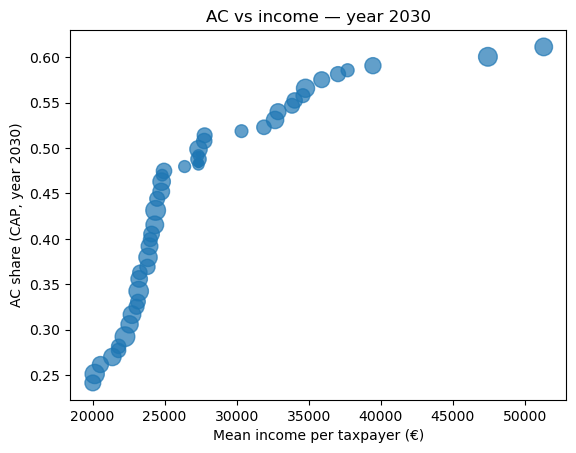

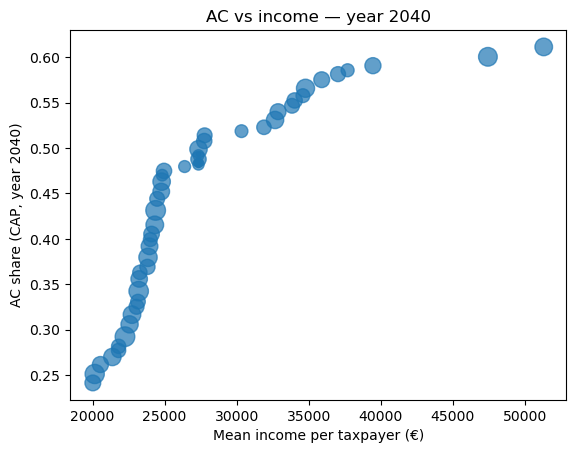

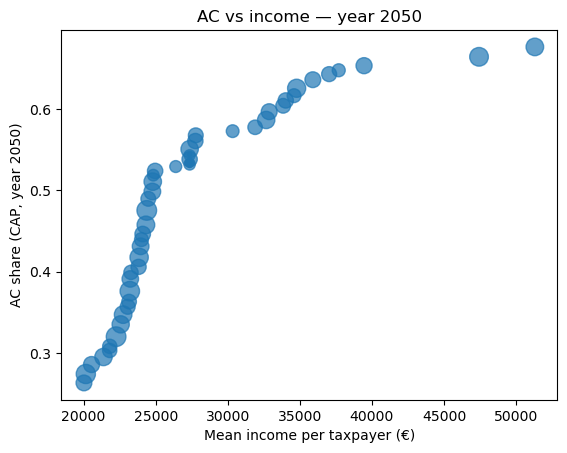

In [28]:
pd.options.display.float_format = "{:,.3f}".format

def weighted_corr(x, y, w):
    x = np.asarray(x, float); y = np.asarray(y, float); w = np.asarray(w, float)
    m_x = np.average(x, weights=w); m_y = np.average(y, weights=w)
    cov = np.average((x - m_x) * (y - m_y), weights=w)
    sx = np.sqrt(np.average((x - m_x)**2, weights=w))
    sy = np.sqrt(np.average((y - m_y)**2, weights=w))
    return cov / (sx * sy) if (sx > 0 and sy > 0) else np.nan

for y in YEARS_AC:
    print(f"\n=== QA for year {y} ===")
    cap_sub = make_cap_sub_for_year(y)

    n_show = min(8, len(cap_sub))

    print("Poorest CAPs (by clipped income rank): expect low p_inc & low AC")
    display(cap_sub.sort_values("inc_rank_base", kind="mergesort").head(n_show))

    print("\nRichest CAPs (by clipped income rank): expect high p_inc & high AC")
    display(cap_sub.sort_values("inc_rank_base", ascending=False, kind="mergesort").head(n_show))

    print("\nUnweighted Pearson corr (inc_mean vs AC):")
    display(cap_sub[["inc_mean", "ac_cap_year"]].corr().round(3))

    wc = weighted_corr(cap_sub["inc_mean"], cap_sub["ac_cap_year"], cap_sub["pop_cap"])
    mean_pop = np.average(cap_sub["ac_cap_year"], weights=cap_sub["pop_cap"])
    print(f"Weighted Pearson corr (by grid pop): {wc:.3f}")
    print(f"Pop-weighted mean AC share: {mean_pop:.3f}")

    size = 200 * np.sqrt(cap_sub["pop_cap"] / cap_sub["pop_cap"].max())
    size = np.clip(size, 10, None)

    ax = cap_sub.plot.scatter(x="inc_mean", y="ac_cap_year", s=size, alpha=0.7)
    ax.set_xlabel("Mean income per taxpayer (€)")
    ax.set_ylabel(f"AC share (CAP, year {y})")
    ax.set_title(f"AC vs income — year {y}")

**Current CAP AC Coverage on CLIMADA GRID**


===== YEAR 2030 =====
[QA] City pop-w mean on grid 2030: 0.427 (target 0.427)
[QA] City pop-w mean from CAP agg: 0.427 (target 0.427)
[QA] City pop-w mean (CITY_MASK): 0.427 (target 0.427)


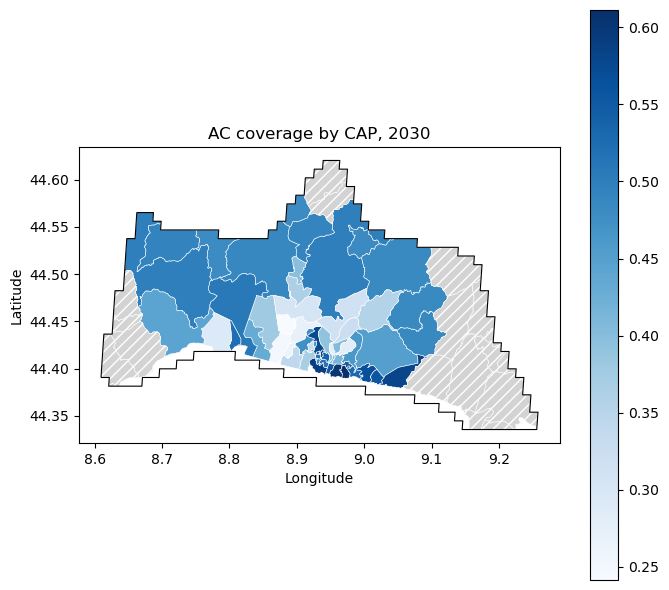


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,61,16161,0.241,"11,082.734",24.139
1,53,16152,0.251,"24,408.306",25.124
2,52,16151,0.262,"11,853.539",26.164
3,60,16159,0.270,"16,404.381",26.996
4,42,16139,0.277,"7,441.682",27.713
5,46,16144,0.282,"7,420.327",28.166
6,58,16157,0.292,"26,751.985",29.228
7,62,16162,0.306,"15,807.041",30.585
8,41,16138,0.317,"17,059.041",31.658
9,43,16141,0.325,"8,877.588",32.519


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,48,16146,0.611,"17,133.486",61.126
1,47,16145,0.600,"21,811.609",60.037
2,32,16128,0.591,"12,004.961",59.061
3,29,16125,0.586,"5,134.224",58.556
4,67,16167,0.581,"9,086.437",58.131
5,39,16136,0.575,"11,194.749",57.517
6,50,16148,0.566,"19,371.715",56.574
7,66,16166,0.558,"6,568.576",55.758
8,33,16129,0.552,"9,864.664",55.234
9,34,16131,0.546,"8,396.485",54.644



===== YEAR 2040 =====
[QA] City pop-w mean on grid 2040: 0.427 (target 0.427)
[QA] City pop-w mean from CAP agg: 0.427 (target 0.427)
[QA] City pop-w mean (CITY_MASK): 0.427 (target 0.427)


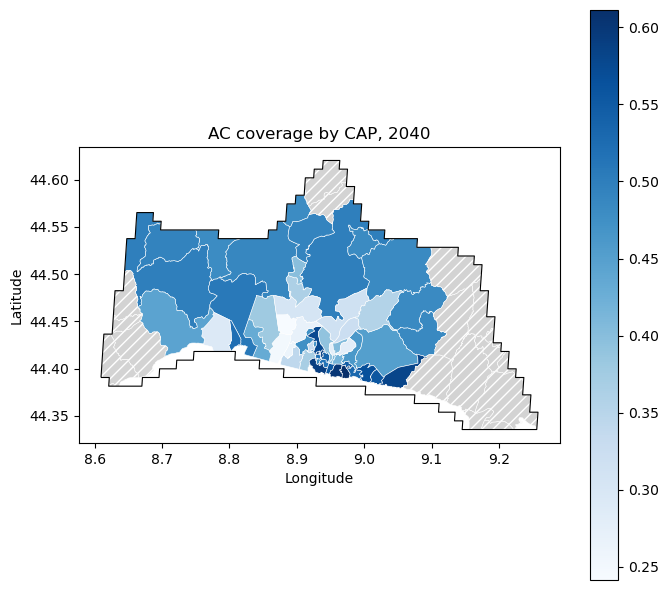


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,61,16161,0.241,"11,082.734",24.139
1,53,16152,0.251,"24,408.306",25.124
2,52,16151,0.262,"11,853.539",26.164
3,60,16159,0.270,"16,404.381",26.996
4,42,16139,0.277,"7,441.682",27.713
5,46,16144,0.282,"7,420.327",28.166
6,58,16157,0.292,"26,751.985",29.228
7,62,16162,0.306,"15,807.041",30.585
8,41,16138,0.317,"17,059.041",31.658
9,43,16141,0.325,"8,877.588",32.519


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,48,16146,0.611,"17,133.486",61.126
1,47,16145,0.600,"21,811.609",60.037
2,32,16128,0.591,"12,004.961",59.061
3,29,16125,0.586,"5,134.224",58.556
4,67,16167,0.581,"9,086.437",58.131
5,39,16136,0.575,"11,194.749",57.517
6,50,16148,0.566,"19,371.715",56.574
7,66,16166,0.558,"6,568.576",55.758
8,33,16129,0.552,"9,864.664",55.234
9,34,16131,0.546,"8,396.485",54.644



===== YEAR 2050 =====
[QA] City pop-w mean on grid 2050: 0.471 (target 0.471)
[QA] City pop-w mean from CAP agg: 0.471 (target 0.471)
[QA] City pop-w mean (CITY_MASK): 0.471 (target 0.471)


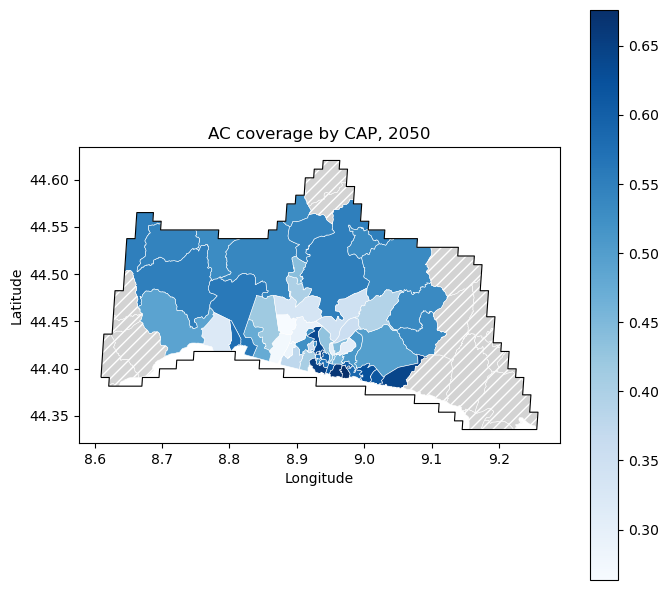


Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,61,16161,0.263,"11,082.734",26.346
1,53,16152,0.274,"24,408.306",27.445
2,52,16151,0.286,"11,853.539",28.604
3,60,16159,0.295,"16,404.381",29.532
4,42,16139,0.303,"7,441.682",30.332
5,46,16144,0.308,"7,420.327",30.838
6,58,16157,0.320,"26,751.985",32.022
7,62,16162,0.335,"15,807.041",33.536
8,41,16138,0.347,"17,059.041",34.732
9,43,16141,0.357,"8,877.588",35.692


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,48,16146,0.676,"17,133.486",67.598
1,47,16145,0.664,"21,811.609",66.383
2,32,16128,0.653,"12,004.961",65.295
3,29,16125,0.647,"5,134.224",64.731
4,67,16167,0.643,"9,086.437",64.257
5,39,16136,0.636,"11,194.749",63.573
6,50,16148,0.625,"19,371.715",62.521
7,66,16166,0.616,"6,568.576",61.611
8,33,16129,0.610,"9,864.664",61.026
9,34,16131,0.604,"8,396.485",60.369


In [29]:
import matplotlib.pyplot as plt

for YEAR_DIAG in YEARS_AC:
    print("\n===== YEAR", YEAR_DIAG, "=====")
    k_diag = year_to_index[YEAR_DIAG]

    coverage_map = coverage_base_3d[k_diag].astype("float32").copy()

    target_ac = float(ac_city_by_year[YEAR_DIAG])
    if target_ac > 1.0:
        target_ac /= 100.0
    target_ac = float(np.clip(target_ac, 0.0, 1.0))

    if np.isnan(coverage_map[CITY_MASK]).any():
        coverage_map = np.where(
            CITY_MASK & np.isnan(coverage_map),
            target_ac,
            coverage_map
        ).astype("float32")

    assert np.isfinite(coverage_map[CITY_MASK]).all(), "Non-finite coverage inside CITY_MASK."

    m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_on_ref > 0)
    w = pop_on_ref[m_city]
    x = coverage_map[m_city]
    mean_pw = float(np.nansum(x * w) / np.nansum(w))

    print(f"[QA] City pop-w mean on grid {YEAR_DIAG}: {mean_pw:.3f} (target {target_ac:.3f})")

    valid = CAP_PIX
    df_capgrid = pd.DataFrame({
        "cap_id": cap_on_ref[valid].ravel().astype(int),
        "pop":    pop_on_ref[valid].ravel().astype(float),
        "cov":    coverage_map[valid].ravel().astype(float),
    })
    df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

    def wavg(g):
        w = g["pop"].to_numpy(dtype=float)
        x = g["cov"].to_numpy(dtype=float)
        return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

    cap_pw   = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
    cap_pop  = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_cap"}))
    cap_disp = (df_capgrid.groupby("cap_id")
                .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                     ac_max=("cov","max"), n_pix=("cov","size"))
                .reset_index())
    cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left").merge(cap_disp, on="cap_id", how="left")
    cap_map = cap_4326.merge(cap_cov, on="cap_id", how="left")

    cov_city_check = float(np.nansum(df_capgrid["cov"] * df_capgrid["pop"]) / np.nansum(df_capgrid["pop"]))
    cov_city_all = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
    print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {target_ac:.3f})")
    print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {target_ac:.3f})")

    ax = fua.to_crs("EPSG:4326").boundary.plot(
        edgecolor="black", facecolor="none", linewidth=0.8, figsize=(7,6)
    )
    cap_map.to_crs("EPSG:4326").plot(
        ax=ax, column="ac_cov_pw", cmap="Blues", legend=True,
        edgecolor="white", linewidth=0.4,
        missing_kwds={"color":"lightgray","edgecolor":"white","hatch":"///","label":"No data"}
    )
    ax.set_title(f"AC coverage by CAP, {YEAR_DIAG}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.figure.tight_layout()
    plt.show()

    tbl = (cap_map[["cap_id","cap5","ac_cov_pw","pop_cap"]]
           .dropna(subset=["ac_cov_pw"])
           .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
           .sort_values("ac_pct"))

    print("\nLowest-coverage CAPs:")
    display(tbl.head(10).reset_index(drop=True))

    print("Highest-coverage CAPs:")
    display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))

In [30]:
import matplotlib.pyplot as plt

# for each of the year 2030, 2040, 2050
for y in YEARS_AC:
    print("\n" + "="*20 + f" YEAR {y} " + "="*20)
    YEAR_DIAG = y
    k_diag    = year_to_index[YEAR_DIAG]

    # coverage on grid for this year 
    coverage_map = coverage_base_3d[k_diag].astype("float32").copy()

    # target citywide mean for that year 
    target_ac = float(ac_city_by_year[YEAR_DIAG])
    if target_ac > 1.0:
        target_ac /= 100.0
    target_ac = float(np.clip(target_ac, 0.0, 1.0))

    # fill any remaining NaNs inside CITY_MASK with the city mean for that year
    if np.isnan(coverage_map[CITY_MASK]).any():
        coverage_map = np.where(
            CITY_MASK & np.isnan(coverage_map),
            target_ac,
            coverage_map
        ).astype("float32")

    # assert no NaNs where we care
    assert np.isfinite(coverage_map[CITY_MASK]).all(), \
        f"Non-finite coverage inside CITY_MASK for year {YEAR_DIAG}."

    # city pop-weighted mean on grid
    m_city = CITY_MASK & np.isfinite(coverage_map) & (pop_on_ref > 0)
    w = pop_on_ref[m_city]
    x = coverage_map[m_city]
    mean_pw = float(np.nansum(x * w) / np.nansum(w))

    print(f"[QA] City pop-w mean on grid {YEAR_DIAG}: {mean_pw:.3f} (target {target_ac:.3f})")

    # CAP aggregation + map for this year 
    valid = CAP_PIX
    df_capgrid = pd.DataFrame({
        "cap_id": cap_on_ref[valid].ravel().astype(int),
        "pop":    pop_on_ref[valid].ravel().astype(float),
        "cov":    coverage_map[valid].ravel().astype(float),
    })
    df_capgrid = df_capgrid[df_capgrid["cap_id"] > 0]

    def wavg(g):
        w = g["pop"].to_numpy(dtype=float)
        x = g["cov"].to_numpy(dtype=float)
        return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

    cap_pw   = df_capgrid.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
    cap_pop  = (df_capgrid.groupby("cap_id", as_index=False)["pop"]
                .sum().rename(columns={"pop":"pop_cap"}))
    cap_disp = (df_capgrid.groupby("cap_id")
                .agg(ac_min=("cov","min"), ac_med=("cov","median"),
                     ac_max=("cov","max"), n_pix=("cov","size"))
                .reset_index())
    cap_cov = cap_pw.merge(cap_pop, on="cap_id", how="left").merge(cap_disp, on="cap_id", how="left")
    cap_map = cap_4326.merge(cap_cov, on="cap_id", how="left")

    cov_city_check = float(np.nansum(df_capgrid["cov"] * df_capgrid["pop"]) / np.nansum(df_capgrid["pop"]))
    cov_city_all   = float(np.nansum(coverage_map[m_city] * pop_on_ref[m_city]) / np.nansum(pop_on_ref[m_city]))
    print(f"[QA] City pop-w mean from CAP agg: {cov_city_check:.3f} (target {target_ac:.3f})")
    print(f"[QA] City pop-w mean (CITY_MASK): {cov_city_all:.3f} (target {target_ac:.3f})")

    # consistency checks by year 
    # pixels we actually painted from CAPs
    df_capgrid_cons = df_capgrid.copy()

    cap_pw_cons  = df_capgrid_cons.groupby("cap_id").apply(wavg).reset_index(name="ac_cov_pw")
    cap_pop_cons = (df_capgrid_cons.groupby("cap_id", as_index=False)["pop"]
                    .sum().rename(columns={"pop":"pop_cap"}))
    cap_cov_cons = cap_pw_cons.merge(cap_pop_cons, on="cap_id", how="left")

    # year-specific CAP targets
    df_target = cap_stats[["cap_id"]].copy()
    df_target["ac_cap_target"] = ac_cap_by_year[YEAR_DIAG]

    cap_join = cap_cov_cons.merge(df_target, on="cap_id", how="left")

    diff = np.abs(cap_join["ac_cov_pw"] - cap_join["ac_cap_target"])
    err_cap = float(np.nanmax(diff)) if np.any(np.isfinite(diff)) else 0.0
    print(f"[{YEAR_DIAG}] Max per-CAP diff (grid vs CAP table): {err_cap:.3e}")

    # grid-level bounds respected
    m_city2 = CITY_MASK & np.isfinite(coverage_map)
    print(f"[{YEAR_DIAG}] Min/Max coverage on grid:",
          float(np.nanmin(coverage_map[m_city2])),
          float(np.nanmax(coverage_map[m_city2])))

    w2 = np.where(m_city2, pop_on_ref, 0.0)
    at_floor = np.isclose(coverage_map, ac_min, atol=1e-6)
    at_cap   = np.isclose(coverage_map, ac_max, atol=1e-6)
    print(f"[{YEAR_DIAG}] Pop share at floor:", float(np.nansum(w2 * at_floor) / np.nansum(w2)))
    print(f"[{YEAR_DIAG}] Pop share at cap:  ", float(np.nansum(w2 * at_cap)   / np.nansum(w2)))

    print(f"[{YEAR_DIAG}] Grid pop-weighted mean:",
          float(np.nansum(coverage_map[m_city2] * pop_on_ref[m_city2]) /
                np.nansum(pop_on_ref[m_city2])))

    # tables: lowest / highest coverage CAPs for this year
    tbl = (cap_map[["cap_id","cap5","ac_cov_pw","pop_cap"]]
           .dropna(subset=["ac_cov_pw"])
           .assign(ac_pct=lambda d: 100*d["ac_cov_pw"])
           .sort_values("ac_pct"))

    print("\nLowest-coverage CAPs:")
    display(tbl.head(10).reset_index(drop=True))

    print("Highest-coverage CAPs:")
    display(tbl.tail(10).sort_values("ac_pct", ascending=False).reset_index(drop=True))


==================== YEAR 2030 ====================
[QA] City pop-w mean on grid 2030: 0.427 (target 0.427)
[QA] City pop-w mean from CAP agg: 0.427 (target 0.427)
[QA] City pop-w mean (CITY_MASK): 0.427 (target 0.427)
[2030] Max per-CAP diff (grid vs CAP table): 2.428e-08
[2030] Min/Max coverage on grid: 0.24139094352722168 0.6112588047981262
[2030] Pop share at floor: 0.0
[2030] Pop share at cap:   0.0
[2030] Grid pop-weighted mean: 0.427151620388031

Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,61,16161,0.241,"11,082.734",24.139
1,53,16152,0.251,"24,408.306",25.124
2,52,16151,0.262,"11,853.539",26.164
3,60,16159,0.270,"16,404.381",26.996
4,42,16139,0.277,"7,441.682",27.713
5,46,16144,0.282,"7,420.327",28.166
6,58,16157,0.292,"26,751.985",29.228
7,62,16162,0.306,"15,807.041",30.585
8,41,16138,0.317,"17,059.041",31.658
9,43,16141,0.325,"8,877.588",32.519


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,48,16146,0.611,"17,133.486",61.126
1,47,16145,0.600,"21,811.609",60.037
2,32,16128,0.591,"12,004.961",59.061
3,29,16125,0.586,"5,134.224",58.556
4,67,16167,0.581,"9,086.437",58.131
5,39,16136,0.575,"11,194.749",57.517
6,50,16148,0.566,"19,371.715",56.574
7,66,16166,0.558,"6,568.576",55.758
8,33,16129,0.552,"9,864.664",55.234
9,34,16131,0.546,"8,396.485",54.644



==================== YEAR 2040 ====================
[QA] City pop-w mean on grid 2040: 0.427 (target 0.427)
[QA] City pop-w mean from CAP agg: 0.427 (target 0.427)
[QA] City pop-w mean (CITY_MASK): 0.427 (target 0.427)
[2040] Max per-CAP diff (grid vs CAP table): 2.428e-08
[2040] Min/Max coverage on grid: 0.24139094352722168 0.6112588047981262
[2040] Pop share at floor: 0.0
[2040] Pop share at cap:   0.0
[2040] Grid pop-weighted mean: 0.427151620388031

Lowest-coverage CAPs:


...

,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,48,16146,0.611,"17,133.486",61.126
1,47,16145,0.600,"21,811.609",60.037
2,32,16128,0.591,"12,004.961",59.061
3,29,16125,0.586,"5,134.224",58.556
4,67,16167,0.581,"9,086.437",58.131
5,39,16136,0.575,"11,194.749",57.517
6,50,16148,0.566,"19,371.715",56.574
7,66,16166,0.558,"6,568.576",55.758
8,33,16129,0.552,"9,864.664",55.234
9,34,16131,0.546,"8,396.485",54.644



==================== YEAR 2050 ====================
[QA] City pop-w mean on grid 2050: 0.471 (target 0.471)
[QA] City pop-w mean from CAP agg: 0.471 (target 0.471)
[QA] City pop-w mean (CITY_MASK): 0.471 (target 0.471)
[2050] Max per-CAP diff (grid vs CAP table): 2.902e-08
[2050] Min/Max coverage on grid: 0.26346030831336975 0.6759777665138245
[2050] Pop share at floor: 0.0
[2050] Pop share at cap:   0.0
[2050] Grid pop-weighted mean: 0.4706410765647888

Lowest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,61,16161,0.263,"11,082.734",26.346
1,53,16152,0.274,"24,408.306",27.445
2,52,16151,0.286,"11,853.539",28.604
3,60,16159,0.295,"16,404.381",29.532
4,42,16139,0.303,"7,441.682",30.332
5,46,16144,0.308,"7,420.327",30.838
6,58,16157,0.320,"26,751.985",32.022
7,62,16162,0.335,"15,807.041",33.536
8,41,16138,0.347,"17,059.041",34.732
9,43,16141,0.357,"8,877.588",35.692


Highest-coverage CAPs:


,cap_id,cap5,ac_cov_pw,pop_cap,ac_pct
0,48,16146,0.676,"17,133.486",67.598
1,47,16145,0.664,"21,811.609",66.383
2,32,16128,0.653,"12,004.961",65.295
3,29,16125,0.647,"5,134.224",64.731
4,67,16167,0.643,"9,086.437",64.257
5,39,16136,0.636,"11,194.749",63.573
6,50,16148,0.625,"19,371.715",62.521
7,66,16166,0.616,"6,568.576",61.611
8,33,16129,0.610,"9,864.664",61.026
9,34,16131,0.604,"8,396.485",60.369


**Little note/question here: quite a lot at the CAP, but I tried to decrease the s of the logistic function and to modify the min/max, doesn't do much... I think by construction a lot are at the CAP. Problem?**

In [31]:
# building table: one row per CAP with income rank + grid pop
# we restrict to CAPs that actually have modeled population (>0) on the CLIMADA grid
cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0, ["cap_id","cap5","p_inc","pop_cap"]]
             .rename(columns={"pop_cap":"pop_cap_grid", "p_inc":"rank_key"})
)

sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","rank_key","pop_cap_grid"]]
       .sort_values("rank_key")   # still ascending: poorer first
       .reset_index(drop=True))

All the targets changed well since we went from netCDF to CSV ! perfect

## AC Policy

some notes on following code:
- we rank CAPs by income but we cumulate the WorldPop pop, not the taxpayers anymore
- New policy!! 

**Catch-up policy** : 70% AC coverage for 50% poorest by CAP income rank with uniform efficacy : 0.3 and age-varying efficacy (an efficacy per age bucket): this needs **calibration**

In [32]:
# AC policy 

import numpy as np, pandas as pd

# reading para from YAML if present 
ac_cfg   = cfg.get("ac", {})
pol_cfg  = cfg.get("ac_policy", {})  
X_SHARE  = float(pol_cfg.get("target_share_by_pop", 0.50))   # 50% poorest by grid pop
TARGET   = float(pol_cfg.get("target_level",        0.70))   # lift to 70%
TOL      = float(pol_cfg.get("tol",                 1e-6))  

# AC bounds 
AC_LO = float(ac_cfg.get("ac_min", 0.05))
AC_HI = float(ac_cfg.get("ac_max", 0.98))

# helpers 
def popw_mean(arr, mask=None):
    m = np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if mask is not None:
        m &= mask
    if not np.any(m):
        return np.nan
    w = pop_on_ref[m].astype(float)
    x = arr[m].astype(float)
    den = np.sum(w)
    return float(np.sum(x * w) / den) if den > 0 else np.nan

def cap_popw_mean_from(arr, valid_mask, name):
    m = valid_mask & np.isfinite(arr) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if not np.any(m):
        return pd.DataFrame(columns=["cap_id", name])
    df = pd.DataFrame({
        "cap_id": cap_on_ref[m].ravel().astype(int),
        name:     arr[m].ravel().astype(float),
        "w":      pop_on_ref[m].ravel().astype(float),
    })
    out = (df.groupby("cap_id")
             .apply(lambda g: float(np.sum(g[name]*g["w"]) / np.sum(g["w"]))
                              if g["w"].sum() > 0 else np.nan)
             .reset_index(name=name))
    return out

# selector input anchored to the grid universe 
need_cols = {"cap_id","cap5","inc_rank_base","pop_cap"}
missing = need_cols - set(cap_stats.columns)
if missing:
    raise KeyError(f"cap_stats missing columns: {sorted(missing)}")

# ensuring p_inc exists (same percentile rule)
if "p_inc" not in cap_stats.columns:
    cap_stats["p_inc"] = weighted_percentile_rank(
        cap_stats["inc_rank_base"].to_numpy(),
        cap_stats["pop_cap"].to_numpy()
    ).clip(1e-3, 1-1e-3)

cap_income_id = (
    cap_stats.loc[cap_stats["pop_cap"] > 0,
                  ["cap_id","cap5","inc_rank_base","p_inc","pop_cap"]]
             .rename(columns={"pop_cap": "pop_cap_grid"})
             .assign(cap_id=lambda d: d["cap_id"].astype(int),
                     pop_cap_grid=lambda d: d["pop_cap_grid"].astype(float))
             .reset_index(drop=True)
)

# sorting poorer to richer
sel = (cap_income_id.loc[cap_income_id["pop_cap_grid"] > 0,
                         ["cap_id","cap5","inc_rank_base","p_inc","pop_cap_grid"]]
       .sort_values(["inc_rank_base","cap_id"], kind="mergesort")
       .reset_index(drop=True))

# cumulative pop population share in CAP universe
if sel.empty:
    raise ValueError("No CAPs with positive grid population in CAP_PIX.")

total_pop = float(sel["pop_cap_grid"].sum())
if total_pop <= 0:
    raise ValueError("Zero total grid population in CAP_PIX; check pop_on_ref / CAP_PIX.")

sel["cum_pop"]   = sel["pop_cap_grid"].cumsum()
sel["cum_share"] = sel["cum_pop"] / total_pop

# choosing cutoff closest to X_SHARE 
cum = sel["cum_share"].to_numpy()
idx_hi   = int(np.searchsorted(cum, X_SHARE, side="left"))
idx_hi   = min(max(idx_hi, 0), len(sel)-1)
share_hi = float(cum[idx_hi])
share_lo = float(cum[idx_hi-1]) if idx_hi > 0 else 0.0
use_hi   = (abs(share_hi - X_SHARE) <= abs(share_lo - X_SHARE))
cut_idx  = idx_hi if use_hi else (idx_hi - 1)

target_ids = np.array(
    sorted(set(sel.loc[:cut_idx, "cap_id"].astype(int).to_numpy())),
    dtype=int
)

# diagnostics 
num = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, target_ids)]))
den = float(np.nansum(pop_on_ref[CAP_PIX]))
share = num / den if den > 0 else np.nan
print(f"Selection share (grid, cap_id-based): {share:.2%} "
      f"(X_SHARE={100*X_SHARE:.0f}%, lo={100*share_lo:.2f}%, hi={100*share_hi:.2f}%, "
      f"picked={'hi' if use_hi else 'lo'})")

Selection share (grid, cap_id-based): 48.67% (X_SHARE=50%, lo=48.67%, hi=53.33%, picked=lo)


In [33]:
# multi-year AC policy: building policy coverage maps for each AC year 

year_to_index = {y: idx for idx, y in enumerate(YEARS_AC)}
n_years = len(YEARS_AC)

max_cap_id = int(cap_stats["cap_id"].max())
cap_ids    = cap_stats["cap_id"].astype(int).to_numpy()

coverage_policy_3d = np.full_like(coverage_base_3d, np.nan, dtype="float32")

for y in YEARS_AC:
    k = year_to_index[y]
    print(f"\n=== AC policy for year {y} ===")

    # baseline CAP-level coverage for this year (vector aligned with cap_stats)
    base_cap_vec = ac_cap_by_year[y].astype(float)  # length = len(cap_stats)

    # per-CAP policy table for this year
    cap_tbl = pd.DataFrame({
        "cap_id": cap_ids,
        "ac_cap_baseline": base_cap_vec,
    })
    cap_tbl["is_target"] = np.isin(cap_tbl["cap_id"].to_numpy(), target_ids)

    cap_tbl["ac_cap_policy"] = np.where(
        cap_tbl["is_target"],
        np.maximum(cap_tbl["ac_cap_baseline"], TARGET),
        cap_tbl["ac_cap_baseline"]
    ).clip(AC_LO, AC_HI)

    # lookup arrays cap_id -> coverage
    ac_lut_base   = np.full(max_cap_id + 1, np.nan, dtype="float32")
    ac_lut_policy = np.full_like(ac_lut_base, np.nan)

    idx = cap_tbl["cap_id"].astype(int).to_numpy()
    ac_lut_base[idx]   = cap_tbl["ac_cap_baseline"].astype("float32").to_numpy()
    ac_lut_policy[idx] = cap_tbl["ac_cap_policy"].astype("float32").to_numpy()

    # fill missing baseline with city mean for that year
    city_mean_y = float(ac_city_by_year[y])
    if city_mean_y > 1.0:
        city_mean_y /= 100.0
    city_mean_y = float(np.clip(city_mean_y, 0.0, 1.0))

    nan_pol = np.isnan(ac_lut_policy)
    ac_lut_policy[nan_pol] = ac_lut_base[nan_pol]
    nan_base = np.isnan(ac_lut_base)
    ac_lut_base[nan_base] = city_mean_y

    # baseline map for this year already exists
    coverage_base_y   = coverage_base_3d[k].astype("float32").copy()

    # policy map for this year: paint CAP values onto grid
    coverage_policy_y = np.full(ref_data.shape, np.nan, dtype="float32")
    inside_cap_haz    = CAP_PIX  # CAP label and inside city
    if np.any(inside_cap_haz):
        coverage_policy_y[inside_cap_haz] = ac_lut_policy[cap_on_ref[inside_cap_haz]]

    # if any city pixels still NaN in policy map, keep baseline
    mask_nan = CITY_MASK & np.isnan(coverage_policy_y)
    coverage_policy_y[mask_nan] = coverage_base_y[mask_nan]

    # valid analysis mask for this year
    CAP_MASK_y = CAP_PIX & np.isfinite(coverage_base_y) & np.isfinite(coverage_policy_y)

    # citywide pop-weighted means (diagnostics)
    mean_base = popw_mean(coverage_base_y,   CAP_MASK_y)
    mean_pol  = popw_mean(coverage_policy_y, CAP_MASK_y)
    print(f"City AC baseline (pop-w, CAP_PIX): {mean_base:.3f}")
    print(f"City AC policy   (pop-w, CAP_PIX): {mean_pol:.3f}")
    print(f"Δ mean (pp): {100*(mean_pol - mean_base):.2f}")

    # simple LUT violations check (per CAP, for this year)
    base = cap_tbl["ac_cap_baseline"].to_numpy()
    pol  = cap_tbl["ac_cap_policy"].to_numpy()
    targ_mask_tbl = cap_tbl["is_target"].to_numpy()

    v1 = (targ_mask_tbl & (base + TOL < TARGET) & (pol + TOL < TARGET))
    v2 = (targ_mask_tbl & (base >= TARGET - TOL) & (pol + TOL < base - 1e-12))
    print(f"[{y}] LUT violations (should be 0, 0):", int(v1.sum()), int(v2.sum()))

    # save in 3D array
    coverage_policy_3d[k] = coverage_policy_y

# in case we needed (from before) 
coverage_base   = coverage_base_3d[YEARS_AC.index(2050)]
coverage_policy = coverage_policy_3d[YEARS_AC.index(2050)]


=== AC policy for year 2030 ===
City AC baseline (pop-w, CAP_PIX): 0.427
City AC policy   (pop-w, CAP_PIX): 0.609
Δ mean (pp): 18.22
[2030] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2040 ===
City AC baseline (pop-w, CAP_PIX): 0.427
City AC policy   (pop-w, CAP_PIX): 0.609
Δ mean (pp): 18.22
[2040] LUT violations (should be 0, 0): 0 0

=== AC policy for year 2050 ===
City AC baseline (pop-w, CAP_PIX): 0.471
City AC policy   (pop-w, CAP_PIX): 0.637
Δ mean (pp): 16.67
[2050] LUT violations (should be 0, 0): 0 0


In [34]:
# config-driven names
KEYS = cfg.get("keys", {})  # optional in YAML
CAP_CODE   = KEYS.get("cap_code", "cap5")
CAP_IDCOL  = KEYS.get("cap_id",  "cap_id")
MUNI_ID    = KEYS.get("muni_id", "muni_id")
MUNI_NAME  = KEYS.get("muni_name", "muni_name")

# display
_has_display = "display" in globals()

# CRS helper for plotting 
def _to_wgs84(gdf):
    if gdf is None or gdf.empty:
        return gdf
    crs = getattr(gdf, "crs", None)
    if crs is None:
        return gdf  
    try:
        return gdf.to_crs("EPSG:4326")
    except Exception:
        return gdf  

# diagnostics: p_inc for the targeted set
sel["is_target"] = False
sel.loc[:cut_idx, "is_target"] = True

target_view = (sel.loc[sel["is_target"],
                       [CAP_IDCOL, CAP_CODE, "inc_rank_base", "p_inc", "pop_cap_grid", "cum_share"]]
                 .assign(p_inc_pct=lambda d: (100*d["p_inc"]).round(1),
                         pop_k=lambda d: (d["pop_cap_grid"]/1000).round(1))
              )

print("Targeted CAPs (poorest first) – showing first/last 10 with p_inc:")
tv = pd.concat([target_view.head(10), target_view.tail(10)]).reset_index(drop=True)
if _has_display:
    display(tv)
else:
    print(tv)

p_boundary = float(sel.loc[cut_idx, "p_inc"])
share_boundary = float(sel.loc[cut_idx, "cum_share"])
print(f"Boundary p_inc ≈ {p_boundary:.3f} (~{p_boundary*100:.1f}th pct by people); "
      f"cum. share at boundary = {share_boundary:.2%}")

# what if we used p_inc <= boundary as the selection rule?
ids_by_pinc = (cap_income_id.loc[
                    (cap_income_id["p_inc"] <= p_boundary) &
                    (cap_income_id["pop_cap_grid"] > 0),
                    CAP_IDCOL]
               .astype(int).unique())
num2 = float(np.nansum(pop_on_ref[CAP_PIX & np.isin(cap_on_ref, ids_by_pinc)]))
den  = float(np.nansum(pop_on_ref[CAP_PIX]))
print(f"Selection share if using p_inc<=boundary: {num2/den:.2%} (vs grid-anchored {share:.2%})")

Targeted CAPs (poorest first) – showing first/last 10 with p_inc:
    cap_id   cap5  inc_rank_base  p_inc  pop_cap_grid  cum_share  p_inc_pct  \
0       61  16161     20,088.456  0.010    11,082.734      0.019      1.000   
1       53  16152     20,152.347  0.040    24,408.306      0.062      4.000   
2       52  16151     20,549.167  0.072    11,853.539      0.082      7.200   
3       60  16159     21,377.418  0.097    16,404.381      0.111      9.700   
4       42  16139     21,808.104  0.117     7,441.682      0.124     11.700   
5       46  16144     21,812.906  0.130     7,420.327      0.137     13.000   
6       58  16157     22,251.827  0.160    26,751.985      0.183     16.000   
7       62  16162     22,570.624  0.197    15,807.041      0.211     19.700   
8       41  16138     22,739.312  0.225    17,059.041      0.240     22.500   
9       43  16141     23,053.875  0.248     8,877.588      0.256     24.800   
10      37  16134     23,154.664  0.263     8,133.885      0.270 

In [35]:
# CAP-level coverage table and maps for a chosen diagnostic year

YEAR_DIAG = 2050  # we can change to 2030/2040/2050 as needed
# just didn't want to print all the outputs together 
k_diag    = year_to_index[YEAR_DIAG]

coverage_base_diag   = coverage_base_3d[k_diag].astype("float32")
coverage_policy_diag = coverage_policy_3d[k_diag].astype("float32")

# mask where both baseline and policy are defined for this year
CAP_MASK_diag = CAP_PIX & np.isfinite(coverage_base_diag) & np.isfinite(coverage_policy_diag)

# CAP-level coverage table (baseline, policy, change)
valid_b = CAP_MASK_diag & np.isfinite(coverage_base_diag)
valid_p = CAP_MASK_diag & np.isfinite(coverage_policy_diag)

cap_base = cap_popw_mean_from(coverage_base_diag,   valid_b, "ac_base")
cap_pol  = cap_popw_mean_from(coverage_policy_diag, valid_p, "ac_policy")

cap_cov  = (cap_base.merge(cap_pol, on=CAP_IDCOL, how="outer")
                    .assign(delta=lambda d: d["ac_policy"] - d["ac_base"]))

cap_pop = (pd.DataFrame({
                CAP_IDCOL: cap_on_ref[CAP_MASK_diag].ravel().astype(int),
                "pop":     pop_on_ref[CAP_MASK_diag].ravel().astype(float)
           })
           .groupby(CAP_IDCOL, as_index=False)["pop"].sum()
           .rename(columns={"pop":"pop_cap"}))

cap_cov = (cap_cov.merge(cap_pop, on=CAP_IDCOL, how="left")
                 .merge(cap_4326[[CAP_IDCOL, CAP_CODE]], on=CAP_IDCOL, how="left"))

# building map GeoDataFrame for this year
cap_map = cap_4326.merge(
    cap_cov[[CAP_IDCOL,"ac_base","ac_policy","delta"]],
    on=CAP_IDCOL, how="left"
)

# ranges for baseline/policy
_min_base, _min_pol = cap_cov["ac_base"].min(),   cap_cov["ac_policy"].min()
_max_base, _max_pol = cap_cov["ac_base"].max(),   cap_cov["ac_policy"].max()
vmin = float(np.nanmin([_min_base, _min_pol])) if np.isfinite([_min_base, _min_pol]).any() else 0.0
vmax = float(np.nanmax([_max_base, _max_pol])) if np.isfinite([_max_base, _max_pol]).any() else 1.0

dv   = float(np.nanpercentile(
                np.abs(cap_map["delta"].to_numpy(dtype=float)), 99
             )) if "delta" in cap_map else 0.0
if not np.isfinite(dv) or dv == 0.0:
    dv = 0.0  # keeps plotting but avoids NaN ranges

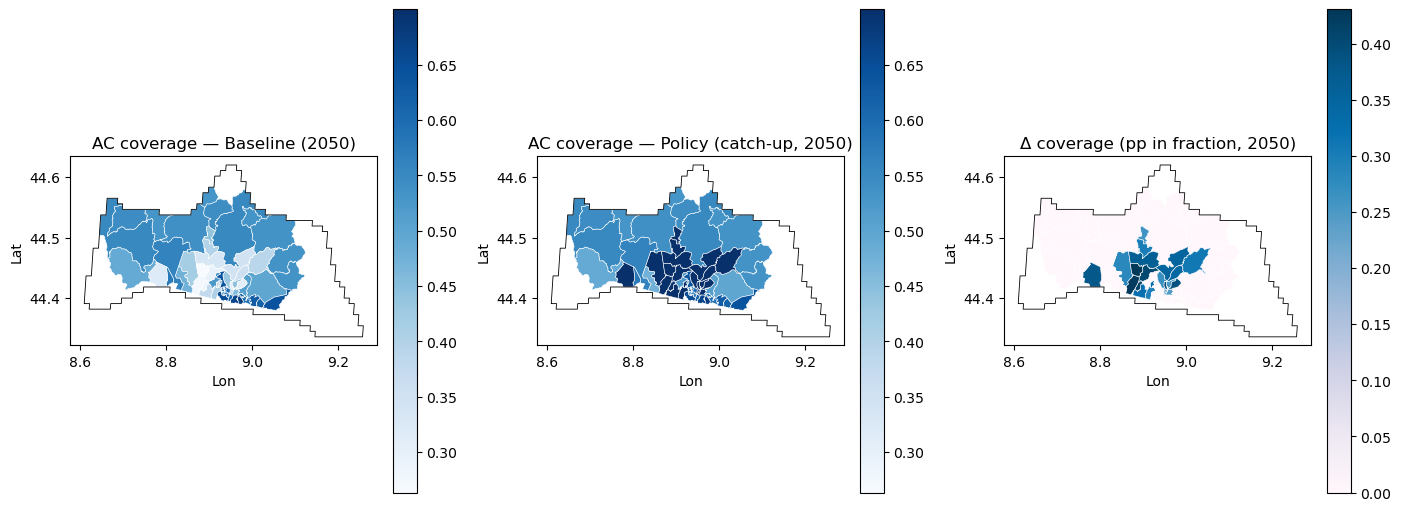

In [36]:
# plot maps
fig, ax = plt.subplots(1,3, figsize=(14,5), constrained_layout=True)

_fua_wgs    = _to_wgs84(fua) if "fua" in globals() else None
_capmap_wgs = _to_wgs84(cap_map)

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[0], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[0], column="ac_base", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True
)
ax[0].set_title(f"AC coverage — Baseline ({YEAR_DIAG})")
ax[0].set_xlabel("Lon"); ax[0].set_ylabel("Lat")

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[1], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[1], column="ac_policy", cmap="Blues",
    vmin=vmin, vmax=vmax, edgecolor="white", lw=0.4, legend=True
)
ax[1].set_title(f"AC coverage — Policy (catch-up, {YEAR_DIAG})")
ax[1].set_xlabel("Lon"); ax[1].set_ylabel("Lat")

if _fua_wgs is not None:
    _fua_wgs.boundary.plot(ax=ax[2], color="k", lw=0.6)
_capmap_wgs.plot(
    ax=ax[2], column="delta", cmap="PuBu",
    vmin=0.0, vmax=dv if dv > 0 else None,
    edgecolor="white", lw=0.4, legend=True
)
ax[2].set_title(f"Δ coverage (pp in fraction, {YEAR_DIAG})")
ax[2].set_xlabel("Lon"); ax[2].set_ylabel("Lat")
plt.show()

In [37]:
# tables: top/bottom changes by CAP for this YEAR_DIAG
tbl = (cap_cov.dropna(subset=["delta"])
              .assign(ac_base_pct=lambda d: 100*d["ac_base"],
                      ac_policy_pct=lambda d: 100*d["ac_policy"],
                      delta_pp=lambda d: 100*d["delta"])
              .sort_values(["delta_pp", CAP_CODE], ascending=[False, True]))

print(f"\nTop Δcoverage CAPs (year {YEAR_DIAG}):")
top_tbl = tbl[[CAP_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]] \
              .head(10).reset_index(drop=True)
if _has_display:
    display(top_tbl)
else:
    print(top_tbl)

print(f"\nBottom (or zero) Δcoverage CAPs (year {YEAR_DIAG}):")
bot_tbl = (tbl[[CAP_CODE,"ac_base_pct","ac_policy_pct","delta_pp","pop_cap"]]
           .tail(10).sort_values("delta_pp").reset_index(drop=True))
if _has_display:
    display(bot_tbl)
else:
    print(bot_tbl)


Top Δcoverage CAPs (year 2050):
    cap5  ac_base_pct  ac_policy_pct  delta_pp    pop_cap
0  16161       26.346         70.000    43.654 11,082.734
1  16152       27.445         70.000    42.555 24,408.306
2  16151       28.604         70.000    41.396 11,853.539
3  16159       29.532         70.000    40.468 16,404.381
4  16139       30.332         70.000    39.668  7,441.682
5  16144       30.838         70.000    39.162  7,420.327
6  16157       32.022         70.000    37.978 26,751.985
7  16162       33.536         70.000    36.464 15,807.041
8  16138       34.732         70.000    35.268 17,059.041
9  16141       35.692         70.000    34.308  8,877.588

Bottom (or zero) Δcoverage CAPs (year 2050):
    cap5  ac_base_pct  ac_policy_pct  delta_pp    pop_cap
0  16145       66.383         66.383     0.000 21,811.609
1  16146       67.598         67.598     0.000 17,133.486
2  16147       58.630         58.630     0.000 16,132.890
3  16148       62.521         62.521     0.000 19,3

In [38]:
# some checks 
# sets at each stage
caps_csv   = set(inc_agg[CAP_CODE].astype(str))
caps_shp   = set(cap_4326[CAP_CODE].astype(str)) # after FUA clip
caps_rast  = set(cap_ref[CAP_CODE].astype(str))  # after reprojection (same as caps_shp)
ids_on_grid = set(np.unique(cap_on_ref[cap_on_ref > 0]).astype(int))
caps_labeled = set(cap_ref.loc[cap_ref[CAP_IDCOL].isin(ids_on_grid), CAP_CODE].astype(str))

# CAPs with any pixel under CITY_MASK 
ids_cap_pix  = set(np.unique(cap_on_ref[CAP_PIX]).astype(int))
caps_cap_pix = set(cap_ref.loc[cap_ref[CAP_IDCOL].isin(ids_cap_pix), CAP_CODE].astype(str))

# CAPs with >0 modeled pop in CAP_PIX
df_capgrid = pd.DataFrame({
    CAP_IDCOL: cap_on_ref[CAP_PIX].ravel().astype(int),
    "pop":     pop_on_ref[CAP_PIX].ravel().astype(float),
})
df_capgrid = df_capgrid[df_capgrid[CAP_IDCOL] > 0]
pop_by_cap = (df_capgrid.groupby(CAP_IDCOL)["pop"].sum()
              .rename("pop_cap").reset_index())
caps_poppos = set(
    cap_ref.merge(pop_by_cap, on=CAP_IDCOL, how="left")
           .query("pop_cap > 0")[CAP_CODE].astype(str)
)

# buckets 
missing_in_shapes_or_outside_fua = sorted(caps_csv - caps_shp)
in_shapes_but_no_labeled_pixels  = sorted(caps_shp - caps_labeled)
labeled_but_not_in_CITY_MASK     = sorted(caps_labeled - caps_cap_pix)
in_CAP_PIX_but_zero_population   = sorted(caps_cap_pix - caps_poppos)

print("CSV CAPs:", len(caps_csv))
print("After FUA clip (polygons):", len(caps_shp))
print("Labeled on grid (any pixels):", len(caps_labeled))
print("In CAP_PIX (city mask & labeled):", len(caps_cap_pix))
print(">0 population in CAP_PIX:", len(caps_poppos))
print()
print("Missing (CSV but not in shapes/FUA):", len(missing_in_shapes_or_outside_fua), missing_in_shapes_or_outside_fua[:10])
print("No labeled pixels (resolution / all_touched=False):", len(in_shapes_but_no_labeled_pixels), in_shapes_but_no_labeled_pixels[:10])
print("Only outside CITY_MASK/hazard or pop==0 area:", len(labeled_but_not_in_CITY_MASK), labeled_but_not_in_CITY_MASK[:10])
print("Zero modeled pop in CAP_PIX:", len(in_CAP_PIX_but_zero_population), in_CAP_PIX_but_zero_population[:10])

CSV CAPs: 43
After FUA clip (polygons): 70
Labeled on grid (any pixels): 52
In CAP_PIX (city mask & labeled): 52
>0 population in CAP_PIX: 52

Missing (CSV but not in shapes/FUA): 0 []
No labeled pixels (resolution / all_touched=False): 18 ['16011', '16012', '16016', '16019', '16024', '16029', '16030', '16031', '16032', '16035']
Only outside CITY_MASK/hazard or pop==0 area: 0 []
Zero modeled pop in CAP_PIX: 0 []


Super important to understand why:
- In my income CSV there are 72 rows of 72 CAP with incomes data
- But then shapefile + FUA clip contains all CAP zones that intersect the FUA (metro area), not just the Comune di Roma → 118 CAPs. Many of those extra CAPs are the suburban/postal zones that start with 000xx (typical around Rome).
- After rasterization, 36 of those polygons don’t catch a grid cell at the resolution (all_touched=False) → “No labeled pixels”. One more has pixels but none in CITY_MASK (outside hazard or pop_on_ref==0)

**Municipi**

In [39]:
# City-agnostic config
REGION_GDF        = globals().get("regions", muni)   # GeoDataFrame of regions+outside
REGION_ID_FIELD   = "muni_id"                        # integer id per region
REGION_NAME_FIELD = "muni_name"                      # readable name
OUTSIDE_LABEL     = "Fuori Municipi (FUA)"           # label when id==0 
PLOT_LABEL        = "Municipi"                       # for plot titles


===== Municipi stats for year 2030 =====
[QA 2030] City (grid) base=0.427 vs sum-over-Municipi=0.427
[QA 2030] City (grid) pol =0.609 vs sum-over-Municipi=0.609

Top/bottom Municipi by Δ (policy - baseline), pp
   muni_id  ac_base_muni  ac_policy_muni   pop_muni  delta  delta_pp  \
9        9         0.303           0.697 59,900.126  0.394    39.380   
5        5         0.341           0.693 54,548.317  0.352    35.191   
3        3         0.351           0.663 52,716.845  0.312    31.178   
1        1         0.384           0.682 45,902.596  0.298    29.754   
7        7         0.357           0.599 70,396.980  0.241    24.136   
8        8         0.389           0.597 51,797.885  0.207    20.730   
2        2         0.516           0.568 67,664.634  0.052     5.219   
6        6         0.567           0.569 70,074.905  0.002     0.164   
4        4         0.533           0.533 66,699.290  0.000     0.000   

   users_base  users_policy          muni_name  ac_base_pct  ac_pol

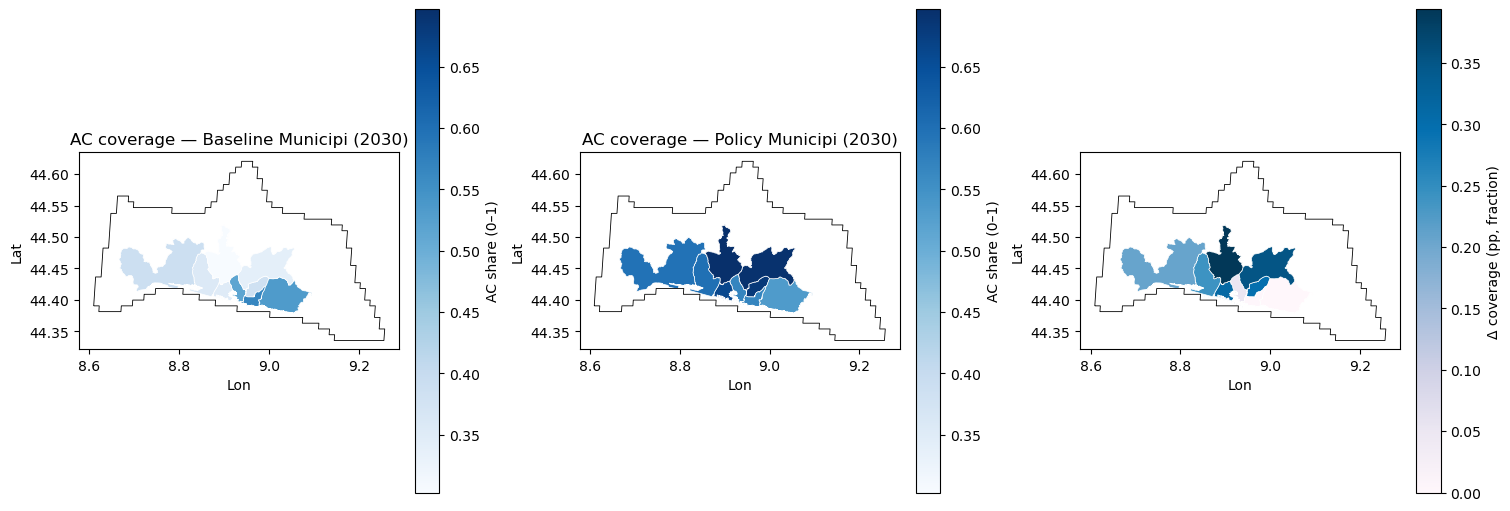


===== Municipi stats for year 2040 =====
[QA 2040] City (grid) base=0.427 vs sum-over-Municipi=0.427
[QA 2040] City (grid) pol =0.609 vs sum-over-Municipi=0.609

Top/bottom Municipi by Δ (policy - baseline), pp
   muni_id  ac_base_muni  ac_policy_muni   pop_muni  delta  delta_pp  \
9        9         0.303           0.697 59,900.126  0.394    39.380   
5        5         0.341           0.693 54,548.317  0.352    35.191   
3        3         0.351           0.663 52,716.845  0.312    31.178   
1        1         0.384           0.682 45,902.596  0.298    29.754   
7        7         0.357           0.599 70,396.980  0.241    24.136   
8        8         0.389           0.597 51,797.885  0.207    20.730   
2        2         0.516           0.568 67,664.634  0.052     5.219   
6        6         0.567           0.569 70,074.905  0.002     0.164   
4        4         0.533           0.533 66,699.290  0.000     0.000   

   users_base  users_policy          muni_name  ac_base_pct  ac_pol

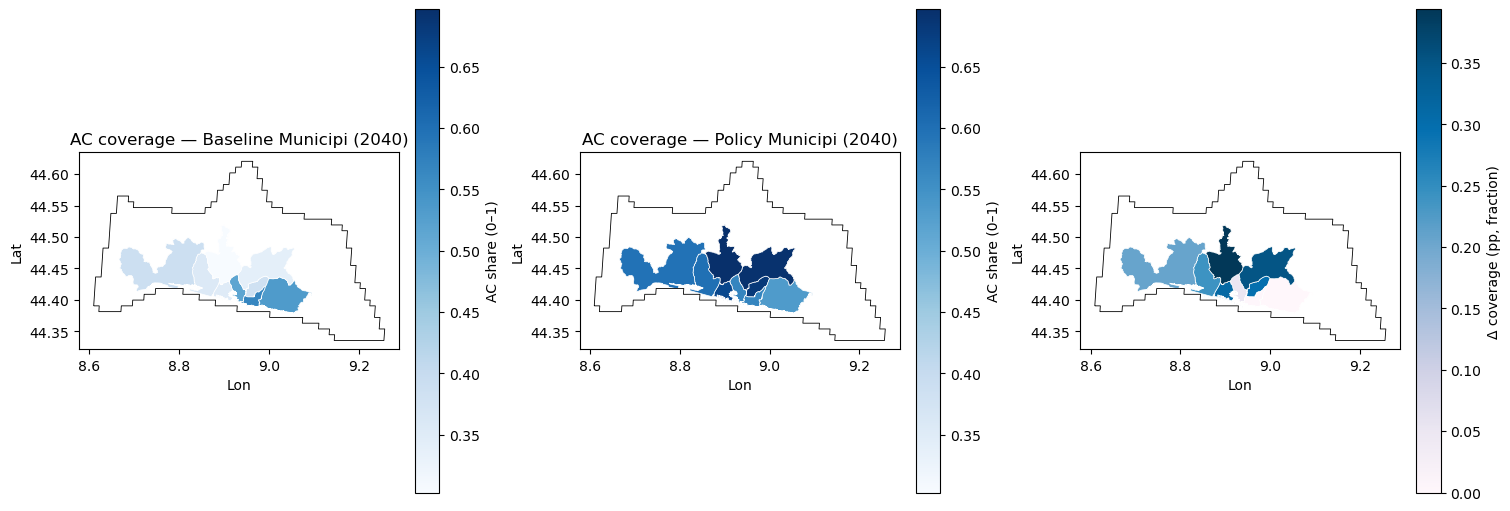


===== Municipi stats for year 2050 =====
[QA 2050] City (grid) base=0.471 vs sum-over-Municipi=0.471
[QA 2050] City (grid) pol =0.637 vs sum-over-Municipi=0.637

Top/bottom Municipi by Δ (policy - baseline), pp
   muni_id  ac_base_muni  ac_policy_muni   pop_muni  delta  delta_pp  \
9        9         0.332           0.698 59,900.126  0.365    36.543   
5        5         0.375           0.694 54,548.317  0.320    31.972   
3        3         0.386           0.671 52,716.845  0.285    28.516   
1        1         0.423           0.686 45,902.596  0.263    26.263   
7        7         0.393           0.616 70,396.980  0.223    22.277   
8        8         0.428           0.622 51,797.885  0.193    19.310   
2        2         0.570           0.617 67,664.634  0.047     4.738   
6        6         0.627           0.628 70,074.905  0.001     0.141   
4        4         0.589           0.589 66,699.290  0.000     0.000   

   users_base  users_policy          muni_name  ac_base_pct  ac_pol

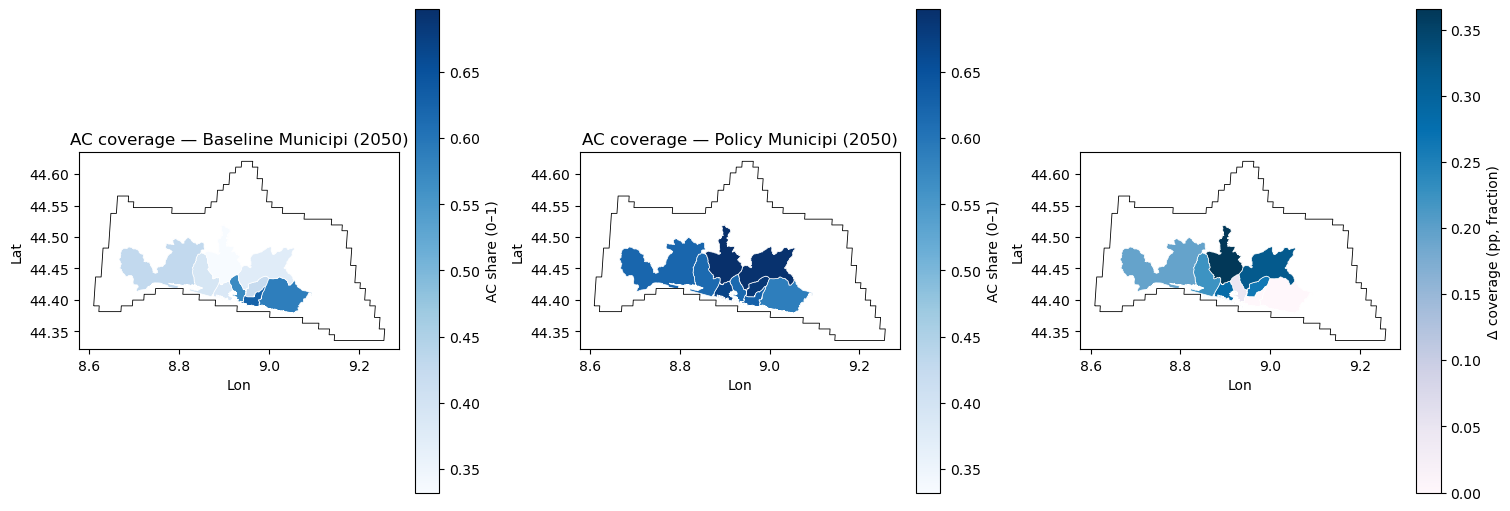

Wrote municipio coverage by year for CBA: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_muni_cov_yearly.csv


In [40]:
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
from rasterio.features import rasterize

# municipio label raster on the CLIMADA grid (only build once)
if "muni_on_ref" not in globals():
    regions_ref = REGION_GDF.to_crs(ref_meta["crs"])
    shapes = [(geom, int(rid)) for geom, rid in zip(regions_ref.geometry, regions_ref[REGION_ID_FIELD])]
    muni_on_ref = rasterize(
        shapes=shapes,
        out_shape=ref_data.shape,
        transform=ref_meta["transform"],
        fill=-1, dtype="int32", all_touched=False
    )

def _wavg(x, w):
    w = np.asarray(w, float); x = np.asarray(x, float)
    return float(np.average(x, weights=w)) if w.sum() > 0 else np.nan

# for all years
all_muni_cov = []

for YEAR_DIAG in YEARS_AC:
    print(f"\n===== Municipi stats for year {YEAR_DIAG} =====")
    k_diag = year_to_index[YEAR_DIAG]

    # year-specific baseline and policy on the grid
    coverage_base_diag   = coverage_base_3d[k_diag].astype("float32")
    coverage_policy_diag = coverage_policy_3d[k_diag].astype("float32")

    # mask where both are defined inside CAP universe
    CAP_MASK_diag = CAP_PIX & np.isfinite(coverage_base_diag) & np.isfinite(coverage_policy_diag)

    # pop-weighted aggregation of AC baseline/policy to Municipi
    mask = CAP_MASK_diag & (muni_on_ref >= 0)
    df = pd.DataFrame({
        "region_id": muni_on_ref[mask].ravel().astype(int),
        "pop":       pop_on_ref[mask].ravel().astype(float),
        "base":      coverage_base_diag[mask].ravel().astype(float),
        "policy":    coverage_policy_diag[mask].ravel().astype(float),
    })

    muni_cov = (df.groupby("region_id")
                  .apply(lambda g: pd.Series({
                      "ac_base":   _wavg(g["base"],   g["pop"]),
                      "ac_policy": _wavg(g["policy"], g["pop"]),
                      "pop_muni":  float(g["pop"].sum())
                  }))
                  .reset_index())

    muni_cov = (muni_cov
                .rename(columns={"region_id":"muni_id",
                                 "ac_base":"ac_base_muni",
                                 "ac_policy":"ac_policy_muni"})
                .assign(delta=lambda d: d["ac_policy_muni"] - d["ac_base_muni"],
                        delta_pp=lambda d: 100*(d["ac_policy_muni"] - d["ac_base_muni"])))

    # users
    dfm = df.copy()
    dfm = dfm.rename(columns={"region_id":"muni_id"})
    dfm["users_base"]   = dfm["base"]   * dfm["pop"]
    dfm["users_policy"] = dfm["policy"] * dfm["pop"]

    muni_pop   = dfm.groupby("muni_id", as_index=False)["pop"].sum().rename(columns={"pop":"pop_muni"})
    muni_users = (dfm.groupby("muni_id", as_index=False)
                    .agg(users_base=("users_base","sum"),
                         users_policy=("users_policy","sum")))

    # names
    name_cols = REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD]].rename(
        columns={REGION_ID_FIELD:"muni_id", REGION_NAME_FIELD:"muni_name"}
    )

    muni_cov = (muni_cov
                .merge(muni_users, on="muni_id", how="left")
                .merge(name_cols,  on="muni_id", how="left"))

    muni_cov["muni_name"] = muni_cov["muni_name"].fillna(OUTSIDE_LABEL)

    # super important step for CBA 
    muni_cov_year = muni_cov.copy()
    muni_cov_year["year"] = YEAR_DIAG

    all_muni_cov.append(
        muni_cov_year[["year",
                       "muni_id",
                       "muni_name",
                       "pop_muni",
                       "ac_base_muni",
                       "ac_policy_muni"]]
    )

    # city average from Municipi vs grid
    city_base  = popw_mean(coverage_base_diag,   CAP_MASK_diag)
    city_pol   = popw_mean(coverage_policy_diag, CAP_MASK_diag)
    agg_base   = float(np.nansum(muni_cov["ac_base_muni"]   * muni_cov["pop_muni"]) / np.nansum(muni_cov["pop_muni"]))
    agg_policy = float(np.nansum(muni_cov["ac_policy_muni"] * muni_cov["pop_muni"]) / np.nansum(muni_cov["pop_muni"]))
    print(f"[QA {YEAR_DIAG}] City (grid) base={city_base:.3f} vs sum-over-Municipi={agg_base:.3f}")
    print(f"[QA {YEAR_DIAG}] City (grid) pol ={city_pol:.3f} vs sum-over-Municipi={agg_policy:.3f}")

    # tables
    muni_only = muni_cov[muni_cov["muni_id"] > 0].copy()
    muni_only["ac_base_pct"]   = 100*muni_only["ac_base_muni"]
    muni_only["ac_policy_pct"] = 100*muni_only["ac_policy_muni"]
    muni_only["delta_pp"]      = 100*muni_only["delta"]

    print("\nTop/bottom Municipi by Δ (policy - baseline), pp")
    top = muni_only.sort_values("delta_pp", ascending=False).head(10)
    bot = muni_only.sort_values("delta_pp", ascending=True).head(10)
    if _has_display:
        display(top[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp",
                     "pop_muni","users_base","users_policy"]].reset_index(drop=True))
        display(bot[["muni_id","muni_name","ac_base_pct","ac_policy_pct","delta_pp",
                     "pop_muni","users_base","users_policy"]].reset_index(drop=True))
    else:
        print(top)
        print(bot)

    # maps
    muni_map = (REGION_GDF[[REGION_ID_FIELD, REGION_NAME_FIELD, "geometry"]]
                .rename(columns={REGION_ID_FIELD:"muni_id", REGION_NAME_FIELD:"muni_name"})
                .merge(muni_only, on="muni_id", how="left"))

    vmin = float(np.nanmin(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))
    vmax = float(np.nanmax(muni_map[["ac_base_muni", "ac_policy_muni"]].to_numpy()))
    dv   = float(np.nanmax(np.abs(muni_map["delta"])))

    fig, ax = plt.subplots(1, 3, figsize=(15,5), constrained_layout=True)

    fua.to_crs("EPSG:4326").boundary.plot(ax=ax[0], color="k", lw=0.6)
    muni_map.to_crs("EPSG:4326").plot(
        ax=ax[0], column="ac_base_muni", cmap="Blues",
        vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
        legend_kwds={"label":"AC share (0–1)"}
    )
    ax[0].set_title(f"AC coverage — Baseline {PLOT_LABEL} ({YEAR_DIAG})")

    fua.to_crs("EPSG:4326").boundary.plot(ax=ax[1], color="k", lw=0.6)
    muni_map.to_crs("EPSG:4326").plot(
        ax=ax[1], column="ac_policy_muni", cmap="Blues",
        vmin=vmin, vmax=vmax, edgecolor="white", lw=0.5, legend=True,
        legend_kwds={"label":"AC share (0–1)"}
    )
    ax[1].set_title(f"AC coverage — Policy {PLOT_LABEL} ({YEAR_DIAG})")

    fua.to_crs("EPSG:4326").boundary.plot(ax=ax[2], color="k", lw=0.6)
    muni_map.to_crs("EPSG:4326").plot(
        ax=ax[2], column="delta", cmap="PuBu",
        vmin=0.0, vmax=dv, edgecolor="white", lw=0.5, legend=True,
        legend_kwds={"label":"Δ coverage (pp, fraction)"}
    )
    for a in ax:
        a.set_xlabel("Lon"); a.set_ylabel("Lat")
    plt.show()
    
# municipio coverage by year for CBA: exporting here
if all_muni_cov:
    muni_cov_yearly = pd.concat(all_muni_cov, ignore_index=True)

    out_yearly = OUT / f"{SLUG}_muni_cov_yearly.csv"
    muni_cov_yearly.to_csv(out_yearly, index=False)
    print("Wrote municipio coverage by year for CBA:", out_yearly)

**Mortality with AC: uniform efficacy vs age-varying efficacy**

Using our scenarios efficacy again

In [41]:
EFF_MAP = globals().get("EFF_BUCKETS", None)
if not isinstance(EFF_MAP, dict) or len(EFF_MAP) == 0:
    EFF_MAP = cfg.get("efficacy", {}) if "cfg" in globals() else {}

EFF_DEFAULT = float(globals().get("EFF_DEFAULT", EFF_MAP.get("default", 0.30)))

In [42]:
print("EFF_SCENARIO =", globals().get("EFF_SCENARIO", "(not set in globals)"))
print("EFF_DEFAULT  =", EFF_DEFAULT)
print("EFF_MAP      =", {k: EFF_MAP.get(k) for k in ["<15","15-64","65+"]})

EFF_SCENARIO = high
EFF_DEFAULT  = 0.3
EFF_MAP      = {'<15': 0.3, '15-64': 0.4, '65+': 0.55}


In [43]:
REGION_GDF        = globals().get("regions", muni)
REGION_ID_FIELD   = "muni_id"
REGION_NAME_FIELD = "muni_name"
OUTSIDE_LABEL     = "Fuori Municipi (FUA)"
mask_city = CITY_MASK

_id2name = dict(
    zip(
        REGION_GDF[REGION_ID_FIELD].astype(int),
        REGION_GDF[REGION_NAME_FIELD].astype(str),
    )
)

In [44]:
mask_city = CITY_MASK

In [45]:
def _interp_mdd(I_grid, f):
    return np.interp(I_grid, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])

def _eff_for_age(age_lbl, eff_map, eff_default):
    if age_lbl in eff_map:
        return float(eff_map[age_lbl])
    for k, v in eff_map.items():
        if k == "default":
            continue
        if k in str(age_lbl):
            return float(v)
    return float(eff_default)

def deaths_with_ac(I_grid, coverage_grid, eff=0.30):
    """Uniform efficacy, one day."""
    m = mask_city & np.isfinite(I_grid)

    # fallback: city pop-weighted mean coverage for this grid
    ac_city_here = float(popw_mean(coverage_grid, CAP_MASK))

    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city_here)
    deaths = np.zeros_like(I_grid, dtype=float)
    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        mult = np.clip(1.0 - eff * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

def deaths_with_ac_varage(I_grid, coverage_grid, eff_by_bucket=None, eff_base=None):
    """Age-varying efficacy, one day."""
    eff_map = (eff_by_bucket or EFF_MAP).copy()
    eff_def = EFF_DEFAULT if eff_base is None else float(eff_base)

    m = mask_city & np.isfinite(I_grid)
    ac_city_here = float(popw_mean(coverage_grid, CAP_MASK))
    cov = np.where(m & np.isfinite(coverage_grid), coverage_grid, ac_city_here)
    deaths = np.zeros_like(I_grid, dtype=float)

    for age_lbl, f in age_ifs.items():
        mdd = _interp_mdd(I_grid, f)
        eff_a = _eff_for_age(age_lbl, eff_map, eff_def)
        mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)
        pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)
        deaths += np.where(m, pop_age * mdd * mult, 0.0)
    return deaths

def _row_to_grid(intensity, i_ev, grid_shape):
    row = intensity[i_ev]
    if hasattr(row, "toarray"):
        row = row.toarray()
    row = np.asarray(row, float).ravel()

    n_cells  = row.size
    expected = grid_shape[0] * grid_shape[1]

    if n_cells == expected:
        return row.reshape(grid_shape)
    if n_cells == 1:
        val = row[0]
        return np.full(grid_shape, val, dtype=float)

    raise ValueError(f"Row size {n_cells} != grid cells {expected} and != 1")

In [46]:
EFF_UNIFORM = EFF_DEFAULT
EFF_BUCKETS = EFF_MAP          # age-specific efficacies from YAML
APPLY_BASELINE_SCALING = True  # if we want scaled numbers

dates = pd.to_datetime(H.date)
sf_path = INT / f"baseline_heat_scaling_{SLUG}.csv"
if APPLY_BASELINE_SCALING:
    if not sf_path.exists():
        raise FileNotFoundError(
            f"APPLY_BASELINE_SCALING=True but missing {sf_path}. "
            "Re-run NB4 or set APPLY_BASELINE_SCALING=False."
        )
    sf = pd.read_csv(sf_path).set_index("year")

YEARS_IMPACT = YEARS_AC  # [2030, 2040, 2050], same as coverage years

results_city   = []
results_muni_u = []
results_muni_a = []

for year_focus in YEARS_IMPACT:
    print(f"\n===== Year {year_focus} =====")

    # picking coverage maps for that year
    k = year_to_index[year_focus]
    coverage_base_y   = coverage_base_3d[k].astype(float)
    coverage_policy_y = coverage_policy_3d[k].astype(float)

    CAP_MASK = CAP_PIX & np.isfinite(coverage_base_y) & np.isfinite(coverage_policy_y)

    # hazard events for that year
    year_mask = (dates.year == year_focus)
    idx_year  = np.where(year_mask)[0]
    if idx_year.size == 0:
        print(f"  (no hazard events for {year_focus})")
        continue

    I_year = np.stack(
        [_row_to_grid(H.intensity, i_ev, ref_data.shape) for i_ev in idx_year],
        axis=0
    )

    # daily deaths, then yearly totals (uniform vs age-varying)
    def deaths_series_uniform(I_series, coverage_grid, eff):
        out = np.zeros_like(I_series, dtype=float)
        for t in range(I_series.shape[0]):
            out[t] = deaths_with_ac(I_series[t], coverage_grid, eff=eff)
        return out

    def deaths_series_agevary(I_series, coverage_grid, eff_by_bucket, eff_base=None):
        out = np.zeros_like(I_series, dtype=float)
        for t in range(I_series.shape[0]):
            out[t] = deaths_with_ac_varage(
                I_series[t], coverage_grid,
                eff_by_bucket=eff_by_bucket, eff_base=eff_base
            )
        return out

    deaths_base_uni_day   = deaths_series_uniform(I_year, coverage_base_y,   eff=EFF_UNIFORM)
    deaths_policy_uni_day = deaths_series_uniform(I_year, coverage_policy_y, eff=EFF_UNIFORM)

    deaths_base_age_day   = deaths_series_agevary(I_year, coverage_base_y,   eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM)
    deaths_policy_age_day = deaths_series_agevary(I_year, coverage_policy_y, eff_by_bucket=EFF_BUCKETS, eff_base=EFF_UNIFORM)

    deaths_base_uni   = deaths_base_uni_day.sum(axis=0)
    deaths_policy_uni = deaths_policy_uni_day.sum(axis=0)
    deaths_base_age   = deaths_base_age_day.sum(axis=0)
    deaths_policy_age = deaths_policy_age_day.sum(axis=0)

    d_avo_uni = deaths_base_uni - deaths_policy_uni
    d_avo_age = deaths_base_age - deaths_policy_age

    # optional scaling, but now for this year
    scale_fac = 1.0
    city_total_avo_uni_raw = float(np.nansum(d_avo_uni[mask_city]))
    city_total_avo_age_raw = float(np.nansum(d_avo_age[mask_city]))

    if APPLY_BASELINE_SCALING:
        if year_focus not in sf.index:
            raise ValueError(
                f"Scaling file {sf_path} has years {list(sf.index)} but not {year_focus}."
            )
        row = sf.loc[year_focus]
        age_cols = [c for c in ["<15", "15-64", "65+"] if c in row.index]
        if not age_cols:
            raise ValueError(f"No age columns <15/15-64/65+ in {sf_path} for year {year_focus}.")

        age_pops = {
            age: float(np.nansum(np.nan_to_num(age_on_ref[age], 0.0)[mask_city]))
            for age in age_cols
        }
        tot_pop = sum(age_pops.values())
        if tot_pop <= 0:
            raise ValueError("Total population on CITY_MASK is zero when computing scaling factor.")

        scale_fac = sum(row[age] * age_pops[age] for age in age_cols) / tot_pop
        d_avo_uni *= scale_fac
        d_avo_age *= scale_fac

    city_total_avo_uni = float(np.nansum(d_avo_uni[mask_city]))
    city_total_avo_age = float(np.nansum(d_avo_age[mask_city]))

    print(f"City avoided deaths (uniform eff) in {year_focus}: "
          f"raw={city_total_avo_uni_raw:.3f}, scaled={city_total_avo_uni:.3f} (factor={scale_fac:.3f})")
    print(f"City avoided deaths (age-varying eff) in {year_focus}: "
          f"raw={city_total_avo_age_raw:.3f}, scaled={city_total_avo_age:.3f} (factor={scale_fac:.3f})")

    # municipio delta AC and efficiency for this year
    df = pd.DataFrame({
        "muni_id":  muni_on_ref[CAP_MASK].ravel().astype(int),
        "pop":      pop_on_ref[CAP_MASK].ravel().astype(float),
        "base":     coverage_base_y[CAP_MASK].ravel().astype(float),
        "policy":   coverage_policy_y[CAP_MASK].ravel().astype(float),
    })

    df_muni_delta = (
        df.assign(delta=df["policy"] - df["base"])
          .groupby("muni_id", as_index=False)
          .apply(lambda g: pd.Series({
              "ΔAC_pw":       float(np.average(g["delta"], weights=g["pop"])) if g["pop"].sum() > 0 else np.nan,
              "pop_cap_mask": float(g["pop"].sum()),
          }))
          .reset_index(drop=True)
    )
    df_muni_delta["muni_name"] = df_muni_delta["muni_id"].map(_id2name)

    city_dpp_from_muni = 100.0 * (
        (df_muni_delta["ΔAC_pw"] * df_muni_delta["pop_cap_mask"]).sum()
        / df_muni_delta["pop_cap_mask"].sum()
    )
    city_dpp_from_map = 100.0 * popw_mean(coverage_policy_y - coverage_base_y, mask=CAP_MASK)
    print("City ΔAC (pp) from municipios vs map:", city_dpp_from_muni, city_dpp_from_map)

    # municipio-level avoided deaths for this year (uniform vs age-varying)

    # using same CAP_MASK: only pixels where baseline and policy coverage are defined
    mask_muni = CAP_MASK & (muni_on_ref >= 0)

    df_u = pd.DataFrame({
        "muni_id":     muni_on_ref[mask_muni].ravel().astype(int),
        "avoided":     d_avo_uni[mask_muni].ravel().astype(float),
        "deaths_base": deaths_base_uni[mask_muni].ravel().astype(float),
        "pop":         pop_on_ref[mask_muni].ravel().astype(float),
    })

    df_a = pd.DataFrame({
        "muni_id":     muni_on_ref[mask_muni].ravel().astype(int),
        "avoided":     d_avo_age[mask_muni].ravel().astype(float),
        "deaths_base": deaths_base_age[mask_muni].ravel().astype(float),
        "pop":         pop_on_ref[mask_muni].ravel().astype(float),
    })

    def _agg_muni(df):
        out = (df.groupby("muni_id", as_index=False)
                 .agg(avoided=("avoided","sum"),
                      deaths_base=("deaths_base","sum"),
                      pop_muni=("pop","sum")))
        out["avo_per_100k"] = np.where(
            out["pop_muni"] > 0,
            1e5 * out["avoided"] / out["pop_muni"],
            np.nan
        )
        return out

    df_muni_avo_uni = _agg_muni(df_u)
    df_muni_avo_age = _agg_muni(df_a)

    # attach names so merge on ["muni_id","muni_name"] works
    df_muni_avo_uni["muni_name"] = df_muni_avo_uni["muni_id"].map(_id2name)
    df_muni_avo_age["muni_name"] = df_muni_avo_age["muni_id"].map(_id2name)

    MIN_PP = 0.5
    muni_eff_uni = (df_muni_avo_uni.merge(df_muni_delta, on=["muni_id","muni_name"], how="left")
                                .assign(delta_pp=lambda d: 100*d["ΔAC_pw"],
                                        avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"]>0, d["delta_pp"], np.nan),
                                        flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))
    muni_eff_age = (df_muni_avo_age.merge(df_muni_delta, on=["muni_id","muni_name"], how="left")
                                .assign(delta_pp=lambda d: 100*d["ΔAC_pw"],
                                        avoided_per_pp=lambda d: d["avoided"] / np.where(d["delta_pp"]>0, d["delta_pp"], np.nan),
                                        flag_small_delta=lambda d: d["delta_pp"] < MIN_PP))

    print("Top municipios (avoided per pp uplift) — uniform EFF:")
    display(muni_eff_uni.sort_values("avoided_per_pp", ascending=False)
            [["muni_id","muni_name","avoided","avo_per_100k","delta_pp","avoided_per_pp"]]
            .head(10).reset_index(drop=True))

    print("Top municipios (avoided per pp uplift) — age-varying EFF:")
    display(muni_eff_age.sort_values("avoided_per_pp", ascending=False)
            [["muni_id","muni_name","avoided","avo_per_100k","delta_pp","avoided_per_pp"]]
            .head(10).reset_index(drop=True))

    # if we want to use later: save results
    results_city.append({
        "year": year_focus,
        "city_total_avo_uni": city_total_avo_uni,
        "city_total_avo_age": city_total_avo_age,
        "scale_fac": scale_fac,
    })
    results_muni_u.append(muni_eff_uni.assign(year=year_focus))
    results_muni_a.append(muni_eff_age.assign(year=year_focus))

# tables
results_city = pd.DataFrame(results_city).set_index("year").sort_index()
muni_eff_uni_all = pd.concat(results_muni_u, ignore_index=True)
muni_eff_age_all = pd.concat(results_muni_a, ignore_index=True)


===== Year 2030 =====
City avoided deaths (uniform eff) in 2030: raw=4.699, scaled=4.699 (factor=1.000)
City avoided deaths (age-varying eff) in 2030: raw=8.361, scaled=8.361 (factor=1.000)
City ΔAC (pp) from municipios vs map: 18.221168907585312 18.221168907585316
Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,9,Val Polcevera,1.369,2.285,39.380,0.035
1,7,Medio Ponente,0.707,1.004,24.136,0.029
2,3,Centro Ovest,0.913,1.731,31.178,0.029
3,8,Ponente,0.552,1.065,20.730,0.027
4,5,Media Val Bisagno,0.661,1.211,35.191,0.019
5,6,Medio Levante,0.002,0.003,0.164,0.014
6,1,Bassa Val Bisagno,0.406,0.886,29.754,0.014
7,0,Outside regions (FUA),0.022,0.062,1.639,0.013
8,2,Centro Est,0.064,0.094,5.219,0.012
9,4,Levante,0.000,0.000,0.000,NaN


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,9,Val Polcevera,2.438,4.069,39.380,0.062
1,3,Centro Ovest,1.625,3.083,31.178,0.052
2,7,Medio Ponente,1.258,1.787,24.136,0.052
3,8,Ponente,0.982,1.897,20.730,0.047
4,5,Media Val Bisagno,1.174,2.152,35.191,0.033
5,6,Medio Levante,0.004,0.006,0.164,0.026
6,1,Bassa Val Bisagno,0.722,1.572,29.754,0.024
7,0,Outside regions (FUA),0.039,0.110,1.639,0.024
8,2,Centro Est,0.113,0.167,5.219,0.022
9,4,Levante,0.000,0.000,0.000,NaN



===== Year 2040 =====
City avoided deaths (uniform eff) in 2040: raw=5.433, scaled=4.057 (factor=0.747)
City avoided deaths (age-varying eff) in 2040: raw=9.676, scaled=7.225 (factor=0.747)
City ΔAC (pp) from municipios vs map: 18.221168907585312 18.221168907585316
Top municipios (avoided per pp uplift) — uniform EFF:


...

,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,9,Val Polcevera,2.086,3.483,39.380,0.053
1,7,Medio Ponente,1.088,1.545,24.136,0.045
2,3,Centro Ovest,1.393,2.643,31.178,0.045
3,8,Ponente,0.845,1.631,20.730,0.041
4,5,Media Val Bisagno,1.028,1.885,35.191,0.029
5,6,Medio Levante,0.004,0.005,0.164,0.023
6,1,Bassa Val Bisagno,0.638,1.390,29.754,0.021
7,0,Outside regions (FUA),0.034,0.096,1.639,0.021
8,2,Centro Est,0.103,0.152,5.219,0.020
9,4,Levante,0.000,0.000,0.000,NaN



===== Year 2050 =====
City avoided deaths (uniform eff) in 2050: raw=5.607, scaled=3.301 (factor=0.589)
City avoided deaths (age-varying eff) in 2050: raw=9.992, scaled=5.882 (factor=0.589)
City ΔAC (pp) from municipios vs map: 16.674032404440688 16.674032404440688
Top municipios (avoided per pp uplift) — uniform EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,9,Val Polcevera,0.961,1.604,36.543,0.026
1,7,Medio Ponente,0.494,0.702,22.277,0.022
2,3,Centro Ovest,0.631,1.196,28.516,0.022
3,8,Ponente,0.390,0.753,19.310,0.020
4,5,Media Val Bisagno,0.470,0.862,31.972,0.015
5,6,Medio Levante,0.002,0.002,0.141,0.012
6,1,Bassa Val Bisagno,0.286,0.624,26.263,0.011
7,0,Outside regions (FUA),0.016,0.044,1.486,0.010
8,2,Centro Est,0.048,0.071,4.738,0.010
9,4,Levante,0.000,0.000,0.000,NaN


Top municipios (avoided per pp uplift) — age-varying EFF:


,muni_id,muni_name,avoided,avo_per_100k,delta_pp,avoided_per_pp
0,9,Val Polcevera,1.713,2.860,36.543,0.047
1,7,Medio Ponente,0.880,1.251,22.277,0.040
2,3,Centro Ovest,1.125,2.134,28.516,0.039
3,8,Ponente,0.696,1.343,19.310,0.036
4,5,Media Val Bisagno,0.837,1.535,31.972,0.026
5,6,Medio Levante,0.003,0.004,0.141,0.021
6,1,Bassa Val Bisagno,0.509,1.109,26.263,0.019
7,0,Outside regions (FUA),0.028,0.078,1.486,0.019
8,2,Centro Est,0.086,0.127,4.738,0.018
9,4,Levante,0.000,0.000,0.000,NaN


More **avoided deaths** with the age-varying efficacy

In [47]:
import numpy as np
import pandas as pd

def deaths_year_by_age(year, coverage_grid, eff_by_bucket, eff_base=None):
    """
    For a given year and AC coverage grid, return a dict:
        { age_label -> annual deaths (absolute) }
    using age-varying efficacy (eff_by_bucket) and CLIMADA hazard H.
    """
    dates = pd.to_datetime(H.date)
    mask_year = (dates.year == year)
    idx = np.where(mask_year)[0]

    if idx.size == 0:
        # no events for that year
        return {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    # where we actually model deaths
    m_city = mask_city & np.isfinite(pop_on_ref)

    # fill coverage holes with city mean (for this grid)
    cov_grid = np.where(m_city & np.isfinite(coverage_grid),
                        coverage_grid,
                        np.nan)
    # if some NaNs remain, replace by pop-weighted mean
    if np.isnan(cov_grid[m_city]).any():
        w = pop_on_ref[m_city].astype(float)
        x = np.nan_to_num(cov_grid[m_city], nan=0.0).astype(float)
        mean_cov = float(np.sum(x * w) / np.sum(w)) if w.sum() > 0 else 0.0
        cov_grid = np.where(m_city & np.isnan(cov_grid), mean_cov, cov_grid)

    out = {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    for i_ev in idx:
        I_grid = _row_to_grid(H.intensity, i_ev, ref_data.shape)

        m = m_city & np.isfinite(I_grid)
        if not np.any(m):
            continue

        cov = np.where(m, cov_grid, 0.0)

        for age_lbl, f in age_ifs.items():
            # efficacy for this age
            eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base or EFF_DEFAULT)

            # per-person per-day mortality at this day's temperature
            mdd = _interp_mdd(I_grid, f)

            # multiplicative protection from AC
            mult = np.clip(1.0 - eff_a * cov, 0.0, 1.0)

            pop_age = np.nan_to_num(age_on_ref[age_lbl], 0.0)

            deaths_day = float(np.nansum(pop_age[m] * mdd[m] * mult[m]))
            out[age_lbl] += deaths_day

    return out

In [48]:
years = [2030, 2040, 2050]
rows = []

for year in years:
    k = year_to_index[year]

    cov_base_year   = coverage_base_3d[k].astype(float)
    cov_policy_year = coverage_policy_3d[k].astype(float)

    cov_generic = np.zeros_like(cov_base_year, dtype=float)

    deaths_generic = deaths_year_by_age(
        year,
        cov_generic,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=0.0,
    )

    deaths_citycurrAC = deaths_year_by_age(
        year,
        cov_base_year,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=EFF_UNIFORM,
    )

    deaths_policyAC = deaths_year_by_age(
        year,
        cov_policy_year,
        eff_by_bucket=EFF_BUCKETS,
        eff_base=EFF_UNIFORM,
    )

    for age_lbl in age_ifs.keys():
        d_generic = deaths_generic[age_lbl]
        d_city    = deaths_citycurrAC[age_lbl]
        d_policy  = deaths_policyAC[age_lbl]

        rows.append({
            "year": year,
            "age_group": age_lbl,
            "deaths_generic":               d_generic,
            "deaths_citycurrAC":            d_city,
            "deaths_policyAC":              d_policy,
            "avoided_citycurrAC_vs_generic": d_generic - d_city,
            "avoided_policy_vs_generic":     d_generic - d_policy,
            "avoided_policy_vs_citycurrAC":  d_city    - d_policy,
        })

avoided_by_age = pd.DataFrame(rows).sort_values(["year","age_group"])

avoided_by_age

,year,age_group,deaths_generic,deaths_citycurrAC,deaths_policyAC,avoided_citycurrAC_vs_generic,avoided_policy_vs_generic,avoided_policy_vs_citycurrAC
1,2030,15-64,7.029,5.915,5.289,1.114,1.741,0.627
2,2030,65+,61.157,47.987,40.274,13.171,20.883,7.713
0,2030,<15,0.342,0.300,0.278,0.041,0.063,0.022
4,2040,15-64,7.991,6.721,6.014,1.271,1.978,0.707
5,2040,65+,71.556,56.088,47.142,15.468,24.414,8.946
3,2040,<15,0.374,0.329,0.305,0.045,0.069,0.024
7,2050,15-64,8.864,7.309,6.593,1.555,2.271,0.716
8,2050,65+,81.036,61.706,52.454,19.330,28.582,9.253
6,2050,<15,0.404,0.350,0.327,0.054,0.078,0.024


In [49]:
for year in years:
    df_y = avoided_by_age[avoided_by_age["year"] == year]

    tot_generic = df_y["deaths_generic"].sum()
    tot_city    = df_y["deaths_citycurrAC"].sum()
    tot_policy  = df_y["deaths_policyAC"].sum()

    print(f"\nYear {year}")
    print(f"  Total deaths – generic:        {tot_generic:8.3f}")
    print(f"  Total deaths – city current AC:        {tot_city:8.3f}")
    print(f"  Total deaths – policy AC:              {tot_policy:8.3f}")
    print(f"  Avoided (city current AC vs generic):  {tot_generic - tot_city:8.3f}")
    print(f"  Avoided (policy AC vs generic):        {tot_generic - tot_policy:8.3f}")
    print(f"  Avoided (policy AC vs city current AC):{tot_city - tot_policy:8.3f}")


Year 2030
  Total deaths – generic:          68.528
  Total deaths – city current AC:          54.202
  Total deaths – policy AC:                45.841
  Avoided (city current AC vs generic):    14.326
  Avoided (policy AC vs generic):          22.687
  Avoided (policy AC vs city current AC):   8.361

Year 2040
  Total deaths – generic:          79.921
  Total deaths – city current AC:          63.137
  Total deaths – policy AC:                53.461
  Avoided (city current AC vs generic):    16.784
  Avoided (policy AC vs generic):          26.461
  Avoided (policy AC vs city current AC):   9.676

Year 2050
  Total deaths – generic:          90.304
  Total deaths – city current AC:          69.366
  Total deaths – policy AC:                59.374
  Avoided (city current AC vs generic):    20.939
  Avoided (policy AC vs generic):          30.931
  Avoided (policy AC vs city current AC):   9.992


In [50]:
age_order = ["<15", "15-64", "65+"]

avoided_by_age["age_group"] = pd.Categorical(
    avoided_by_age["age_group"],
    categories=age_order,
    ordered=True
)

tab_ac = (
    avoided_by_age
    .pivot(index="year", columns="age_group", values="avoided_policy_vs_citycurrAC")
    .sort_index()
)

tab_ac["overall"] = tab_ac[age_order].sum(axis=1)

print(tab_ac.round(1))

out_dir = Path(INT)
tab_ac.to_csv(out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv")
print("Wrote:", out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv")

age_group   <15  15-64   65+  overall
year                                 
2030      0.000  0.600 7.700    8.400
2040      0.000  0.700 8.900    9.700
2050      0.000  0.700 9.300   10.000
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_climada_avoided_AC_genova.csv


In [51]:
from pathlib import Path
from datetime import datetime
import json, re

out_dir = Path(INT)
out_dir.mkdir(parents=True, exist_ok=True)

sc_raw = globals().get("EFF_SCENARIO", "na")
sc = re.sub(r"[^a-zA-Z0-9._-]+", "-", str(sc_raw)).lower()
run_id = datetime.now().strftime("%Y%m%dT%H%M%S")

buckets = {k: float(v) for k, v in dict(EFF_BUCKETS).items()}

meta = {
    "created_at": datetime.now().isoformat(timespec="seconds"),
    "run_id": run_id,
    "city": SLUG,
    "EFF_SCENARIO": sc_raw,
    "EFF_DEFAULT": float(EFF_DEFAULT),
    "EFF_BUCKETS": buckets,
}

# always save tab_ac
tab_latest = out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}.csv"
tab_ver    = out_dir / f"annual_heat_deaths_climada_avoided_AC_{SLUG}_{sc}_{run_id}.csv"
tab_ac.to_csv(tab_latest)
tab_ac.to_csv(tab_ver)

# save summary only if it exists
summary_obj = globals().get("summary", None)
if summary_obj is not None:
    sum_latest = out_dir / f"ac_policy_city_summary_{SLUG}.csv"
    sum_ver    = out_dir / f"ac_policy_city_summary_{SLUG}_{sc}_{run_id}.csv"
    summary_obj.to_csv(sum_latest, index=True)
    summary_obj.to_csv(sum_ver, index=True)
else:
    print("Note: 'summary' not defined -> skipping summary CSV saves.")

meta_path = out_dir / f"ac_run_meta_{SLUG}_{sc}_{run_id}.json"
with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print("Wrote:", tab_latest)
print("Wrote:", tab_ver)
print("Wrote:", meta_path)

Note: 'summary' not defined -> skipping summary CSV saves.
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_climada_avoided_AC_genova.csv
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_climada_avoided_AC_genova_high_20251201T110353.csv
Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ac_run_meta_genova_high_20251201T110353.json


## NEW:

For the AC feedback on temperature:
- computing how additional AC adoption modifies the impact of climate warming on heat mortality => If temperature increases by +1°C, how many extra deaths occur — and how does AC coverage change that?

In [52]:
# Marginal heat deaths per +1°C (for NB8) 
import numpy as np
import pandas as pd
import copy
from pathlib import Path

mask_city = CITY_MASK

# Hazard perturbation (+deltaT °C)
# Creating a perturbed version of CLIMADA hazard object by adding a uniform temperature shift
# (`deltaT`, typically +1°C) to all daily temperature intensities. 
# shallow copy for efficiency — only the intensity matrix is truly duplicated.
def hazard_add_deltaT_fast(H, deltaT: float):
    """copy hazard and add uniform +deltaT (°C) to all nonzero intensity entries."""
    H2 = copy.copy(H)
    H2.intensity = H.intensity.copy()
    H2.intensity.data = H2.intensity.data + float(deltaT)
    return H2

# Pop-weighted mean helper (we already have it somewhere, later we can delete duplicates)
def popw_mean_grid(x, mask):
    m = mask & np.isfinite(x) & np.isfinite(pop_on_ref) & (pop_on_ref > 0)
    if not np.any(m):
        return np.nan
    w = pop_on_ref[m].astype(float)
    return float(np.sum(x[m].astype(float) * w) / np.sum(w))

# Deaths by age for one year
# For each year, this function:
# Loops through all hazard events (days) in that year
# Reshapes the intensity row into a 2D grid matching reference raster
# deaths = population × mortality_dose_response(temperature) × protection_multiplier

#  For each age group, computes deaths as:
def deaths_year_by_age_from_H(H_use, year, coverage_grid, eff_by_bucket, eff_base=None):
    dates = pd.to_datetime(H_use.date)
    idx = np.where(dates.year == int(year))[0]
    if idx.size == 0:
        return {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    m_city = mask_city & np.isfinite(pop_on_ref) & (pop_on_ref > 0)

    # filling coverage holes with city pop-weighted mean 
    cov = np.array(coverage_grid, dtype=float, copy=True)
    mean_cov = popw_mean_grid(cov, m_city)
    cov = np.where(m_city & np.isfinite(cov), cov, mean_cov)

    out = {age_lbl: 0.0 for age_lbl in age_ifs.keys()}

    for i_ev in idx:
        I_grid = _row_to_grid(H_use.intensity, i_ev, ref_data.shape)
        m = m_city & np.isfinite(I_grid)
        if not np.any(m):
            continue

        cov_m = np.where(m, cov, 0.0)

        for age_lbl, f in age_ifs.items():
            eff_a = _eff_for_age(age_lbl, eff_by_bucket, eff_base if eff_base is not None else EFF_DEFAULT)
            mdd   = _interp_mdd(I_grid, f)
            mult  = np.clip(1.0 - eff_a * cov_m, 0.0, 1.0)
            pop_a = np.nan_to_num(age_on_ref[age_lbl], 0.0)

            out[age_lbl] += float(np.nansum(pop_a[m] * mdd[m] * mult[m]))

    return out

# Annual tables + marginal per +1°C

# run the same death calculation twice 
# once with original temperatures
# once with temperatures shifted by +1°C 
# then take the difference. 
# gives the marginal heat deaths per degree Celsius.
def annual_table_and_marginal_perC(H0, years, coverage_cube_or_none, eff_buckets, eff_base, deltaT=1.0):
    H1 = hazard_add_deltaT_fast(H0, deltaT)

    rows0, rows1 = [], []
    for y in years:
        if coverage_cube_or_none is None:
            cov = np.zeros(ref_data.shape, dtype=float)  # "no AC"
        else:
            cov = coverage_cube_or_none[year_to_index[int(y)]].astype(float)

        d0 = deaths_year_by_age_from_H(H0, int(y), cov, eff_buckets, eff_base=eff_base)
        d1 = deaths_year_by_age_from_H(H1, int(y), cov, eff_buckets, eff_base=eff_base)

        rows0.append({"year": int(y), **d0})
        rows1.append({"year": int(y), **d1})

    D0 = pd.DataFrame(rows0).set_index("year").sort_index()
    D1 = pd.DataFrame(rows1).set_index("year").sort_index()
    M1 = (D1 - D0)

    for df in (D0, D1, M1):
        df["total"] = df[list(age_ifs.keys())].sum(axis=1)

    return D0, D1, M1

# running baselines
years = [int(y) for y in YEARS_AC]

# generic: eff_base=0 so mult=1 (no protection)
D0_gen, D1_gen, M1_gen = annual_table_and_marginal_perC(
    H, years, coverage_cube_or_none=None,
    eff_buckets=EFF_BUCKETS, eff_base=0.0, deltaT=1.0
)

# current AC baseline
D0_cur, D1_cur, M1_cur = annual_table_and_marginal_perC(
    H, years, coverage_cube_or_none=coverage_base_3d,
    eff_buckets=EFF_BUCKETS, eff_base=float(EFF_DEFAULT), deltaT=1.0
)

# policy AC baseline 
if "coverage_policy_3d" in globals() and coverage_policy_3d is not None:
    D0_pol, D1_pol, M1_pol = annual_table_and_marginal_perC(
        H, years, coverage_cube_or_none=coverage_policy_3d,
        eff_buckets=EFF_BUCKETS, eff_base=float(EFF_DEFAULT), deltaT=1.0
    )
else:
    D0_pol = D1_pol = M1_pol = None

display(M1_cur)

# saving for NB8
out_dir = Path(INT)
out_dir.mkdir(parents=True, exist_ok=True)

M1_gen.to_csv(out_dir / f"marginal_heat_deaths_perC_generic_{SLUG}.csv", index_label="year")
M1_cur.to_csv(out_dir / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv", index_label="year")
if M1_pol is not None:
    M1_pol.to_csv(out_dir / f"marginal_heat_deaths_perC_policyAC_{SLUG}.csv", index_label="year")

D0_cur.to_csv(out_dir / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv", index_label="year")

print("Wrote:")
print(" -", out_dir / f"marginal_heat_deaths_perC_generic_{SLUG}.csv")
print(" -", out_dir / f"marginal_heat_deaths_perC_currentAC_{SLUG}.csv")
if M1_pol is not None:
    print(" -", out_dir / f"marginal_heat_deaths_perC_policyAC_{SLUG}.csv")
print(" -", out_dir / f"annual_heat_deaths_baseline_currentAC_{SLUG}.csv")

,<15,15-64,65+,total
year,,,,
2030,0.125,3.443,34.719,38.287
2040,0.129,3.692,38.242,42.063
2050,0.133,3.855,40.307,44.295


Wrote:
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/marginal_heat_deaths_perC_generic_genova.csv
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/marginal_heat_deaths_perC_currentAC_genova.csv
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/marginal_heat_deaths_perC_policyAC_genova.csv
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/annual_heat_deaths_baseline_currentAC_genova.csv


**Shift in IF**

In [53]:
YEAR_DIAG_IF = 2030   # or 2040 / 2050
k_diag_if = year_to_index[YEAR_DIAG_IF]

coverage_base_if   = coverage_base_3d[k_diag_if].astype(float)
coverage_policy_if = coverage_policy_3d[k_diag_if].astype(float)

In [54]:
def _age_keys_from_cfg(age_ifs, cfg):
    try:
        declared = list(cfg["impact_functions"]["age_params"].keys())
        return [k for k in declared if k in age_ifs] + [k for k in age_ifs if k not in declared]
    except Exception:
        return list(age_ifs.keys())

age_keys = _age_keys_from_cfg(age_ifs, cfg)

EFF_UNIFORM = float(EFF_DEFAULT)
EFF_BUCKETS_BY_AGE = {k: float(EFF_BUCKETS.get(k, EFF_UNIFORM)) for k in age_keys}

In [55]:
# pop-weighted helper over analysis domain (CAP_MASK so coverage defined) 
DOM_MASK = CAP_MASK & np.isfinite(pop_on_ref)
w = np.where(DOM_MASK, pop_on_ref, 0.0)

def wavg_multiplier(coverage, eff):
    mult = np.clip(1.0 - eff * np.where(DOM_MASK, coverage, 0.0), 0.0, 1.0)
    return float(np.nansum(mult * w) / np.nansum(w)) if np.nansum(w) > 0 else np.nan

[Uniform eff=0.30] pop-w multiplier: baseline=0.872, policy=0.817, policy/base=0.937


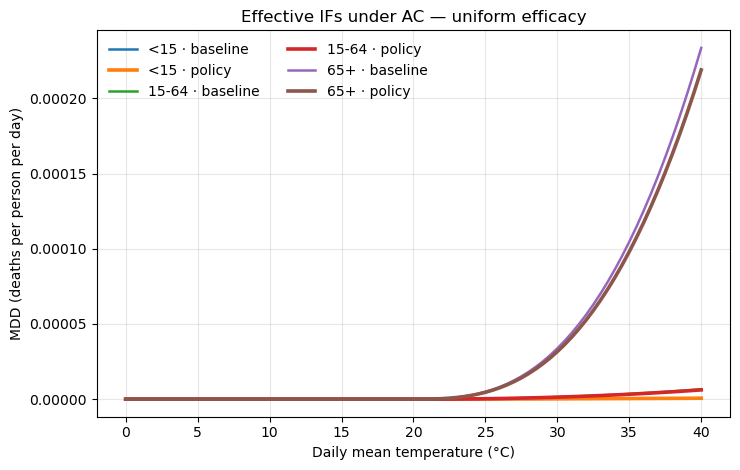

In [56]:
# uniform efficacy shift for the chosen YEAR_DIAG_IF
m_base_uni   = wavg_multiplier(coverage_base_if,   EFF_UNIFORM)
m_policy_uni = wavg_multiplier(coverage_policy_if, EFF_UNIFORM)

print(f"[Uniform eff={EFF_UNIFORM:.2f}] pop-w multiplier: "
      f"baseline={m_base_uni:.3f}, policy={m_policy_uni:.3f}, "
      f"policy/base={m_policy_uni/m_base_uni:.3f}")

plt.figure(figsize=(7.5, 4.8))
for k in age_keys:
    f = age_ifs[k]
    x = f.intensity.astype(float)
    y0 = f.mdd.astype(float)                  # per-person, per-day
    y_base   = y0 * m_base_uni
    y_policy = y0 * m_policy_uni
    plt.plot(x, y_base,   linewidth=1.8, label=f"{k} · baseline")
    plt.plot(x, y_policy, linewidth=2.6, label=f"{k} · policy")
plt.xlabel("Daily mean temperature (°C)")
plt.ylabel("MDD (deaths per person per day)")
plt.title("Effective IFs under AC — uniform efficacy")
plt.grid(alpha=0.3)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

[Age-varying eff] pop-w multipliers:
    <15: baseline=0.872, policy=0.817, policy/base=0.937
  15-64: baseline=0.829, policy=0.756, policy/base=0.912
    65+: baseline=0.765, policy=0.665, policy/base=0.869


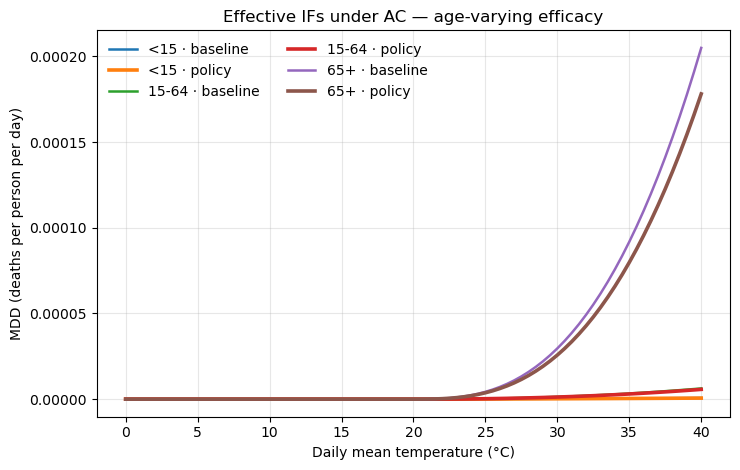

In [57]:
# age-varying efficacy shift for the chosen YEAR_DIAG_IF
m_base_age   = {age: wavg_multiplier(coverage_base_if,   EFF_BUCKETS[age]) for age in age_keys}
m_policy_age = {age: wavg_multiplier(coverage_policy_if, EFF_BUCKETS[age]) for age in age_keys}

print("[Age-varying eff] pop-w multipliers:")
for age in age_keys:
    mb, mp = m_base_age[age], m_policy_age[age]
    print(f"  {age:>5}: baseline={mb:.3f}, policy={mp:.3f}, policy/base={mp/mb:.3f}")

plt.figure(figsize=(7.5, 4.8))
for k in age_keys:
    f = age_ifs[k]
    x = f.intensity.astype(float)
    y0 = f.mdd.astype(float)                  # per-person, per-day
    y_base   = y0 * m_base_age[k]
    y_policy = y0 * m_policy_age[k]
    plt.plot(x, y_base,   linewidth=1.8, label=f"{k} · baseline")
    plt.plot(x, y_policy, linewidth=2.6, label=f"{k} · policy")
plt.xlabel("Daily mean temperature (°C)")
plt.ylabel("MDD (deaths per person per day)")
plt.title("Effective IFs under AC — age-varying efficacy")
plt.grid(alpha=0.3)
plt.legend(ncol=2, frameon=False)
plt.tight_layout()
plt.show()

Conversely to before and to the CLIMADA method, here scaling is continuous, pixel by pixel => we don't create bins and discretise the cap specific scalings into a few categories => for pixel p in CAP c and age a : we multiply the impact function for the age a x by (1- efficacy of a * coverage of p) => we have one IF per CAP*age but we don't instantiate thousands of separate IF objects => we multiply by the local factor inside deaths_with_ac(...). 

> **Notes:**
> - In the uniform efficacy, all ages are scaled down by the same proportion but it looks like only 65 + moves because the 65+ IF is much larger so the % shrink is more obvious visually. 
> - In the second case - age-varying efficacy - the scale down is stronger but especially because of the fact that the efficacy for the 65+ is stronger than the uniform efficacy
> - Careful: it's the INCREMENTAL change: baseline (current AC) vs post-policy

In [58]:
import numpy as np
import pandas as pd
from pathlib import Path

age_order = ["<15", "15-64", "65+"]

# pivot avoided_by_age so we have columns per age group
tab_age = (
    avoided_by_age
    .pivot(index="year", columns="age_group", values="avoided_policy_vs_citycurrAC")
    .reindex(columns=age_order)
)

# renaming columns to something explicit
tab_age = tab_age.rename(columns={
    "<15":   "avoided_policy_vs_citycurrAC_lt15",
    "15-64": "avoided_policy_vs_citycurrAC_15_64",
    "65+":   "avoided_policy_vs_citycurrAC_65p",
})

# total avoided (policy vs current AC) from the age table
tab_age["avoided_policy_vs_citycurrAC_total"] = (
    tab_age[[
        "avoided_policy_vs_citycurrAC_lt15",
        "avoided_policy_vs_citycurrAC_15_64",
        "avoided_policy_vs_citycurrAC_65p",
    ]].sum(axis=1)
)

# join with city-level totals (uniform and age-varying)
summary = (
    results_city
    .join(tab_age, how="left")
    .sort_index()
)

# age shares (% of total avoided, for the age-varying case)
for col_age in [
    "avoided_policy_vs_citycurrAC_lt15",
    "avoided_policy_vs_citycurrAC_15_64",
    "avoided_policy_vs_citycurrAC_65p",
]:
    share_col = col_age + "_share"
    summary[share_col] = (
        summary[col_age] / summary["avoided_policy_vs_citycurrAC_total"]
    )

# display
pd.options.display.float_format = "{:,.2f}".format
display(summary)

# save to CSV
out_summary = INT / f"ac_policy_city_summary_{SLUG}.csv"
summary.to_csv(out_summary)
print("Wrote:", out_summary)

,city_total_avo_uni,city_total_avo_age,scale_fac,avoided_policy_vs_citycurrAC_lt15,avoided_policy_vs_citycurrAC_15_64,avoided_policy_vs_citycurrAC_65p,avoided_policy_vs_citycurrAC_total,avoided_policy_vs_citycurrAC_lt15_share,avoided_policy_vs_citycurrAC_15_64_share,avoided_policy_vs_citycurrAC_65p_share
year,,,,,,,,,,
2030,4.70,8.36,1.00,0.02,0.63,7.71,8.36,0.00,0.07,0.92
2040,4.06,7.23,0.75,0.02,0.71,8.95,9.68,0.00,0.07,0.92
2050,3.30,5.88,0.59,0.02,0.72,9.25,9.99,0.00,0.07,0.93


Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ac_policy_city_summary_genova.csv


**Saving for later**

In [59]:
from pathlib import Path
import numpy as np

SLUG = cfg.get("slug", CITY.lower())
OUT  = Path(OUT)
INT  = Path(INT)
OUT.mkdir(parents=True, exist_ok=True)
INT.mkdir(parents=True, exist_ok=True)

# years / indexing
YEARS_AC = [int(y) for y in YEARS_AC]
year_to_index = {y: i for i, y in enumerate(YEARS_AC)}

# choosing anchor year for legacy 2D exports 
ANCHOR_YEAR = YEARS_AC[-1]              # ex 2050
k_anchor    = year_to_index[ANCHOR_YEAR]

coverage_base_3d_f   = coverage_base_3d.astype("float32")
coverage_policy_3d_f = coverage_policy_3d.astype("float32")

coverage_base_anch   = coverage_base_3d_f[k_anchor]
coverage_policy_anch = coverage_policy_3d_f[k_anchor]

# masks to store
CAP_PIX_u8  = CAP_PIX.astype("uint8") if "CAP_PIX" in globals() else None
CITY_MASK_u8 = CITY_MASK.astype("uint8")

# anchor-year “analysis mask” where both coverages exist
CAP_MASK_ANCHOR = (
    (CAP_PIX if "CAP_PIX" in globals() else CITY_MASK)
    & np.isfinite(coverage_base_anch)
    & np.isfinite(coverage_policy_anch)
).astype("uint8")

npz_path_slug   = INT / f"ac_coverage_maps_{SLUG}.npz"
npz_path_legacy = INT / "ac_coverage_maps.npz"

payload = dict(
    # full time dimension
    coverage_base_3d=coverage_base_3d_f,
    coverage_policy_3d=coverage_policy_3d_f,
    YEARS_AC=np.array(YEARS_AC, dtype="int16"),
    years=np.array(YEARS_AC, dtype="int16"),   

    # 2D anchor year (older notebooks / scripts)
    coverage_base=coverage_base_anch,
    coverage_policy=coverage_policy_anch,
    ANCHOR_YEAR=np.int16(ANCHOR_YEAR),

    # masks + geometry
    CITY_MASK=CITY_MASK_u8,
    CAP_PIX=(CAP_PIX_u8 if CAP_PIX_u8 is not None else CITY_MASK_u8),
    CAP_MASK_ANCHOR=CAP_MASK_ANCHOR,
    HGT=np.int32(HGT),
    WDT=np.int32(WDT),

    EFF_SCENARIO=np.array([str(EFF_SCENARIO)], dtype="U"),
    EFF_DEFAULT=np.array([float(EFF_DEFAULT)], dtype="float32"),
    EFF_BUCKETS_LT15=np.array([float(EFF_BUCKETS.get("<15", EFF_DEFAULT))], dtype="float32"),
    EFF_BUCKETS_15_64=np.array([float(EFF_BUCKETS.get("15-64", EFF_DEFAULT))], dtype="float32"),
    EFF_BUCKETS_65P=np.array([float(EFF_BUCKETS.get("65+", EFF_DEFAULT))], dtype="float32"),
)

np.savez_compressed(npz_path_slug, **payload)
np.savez_compressed(npz_path_legacy, **payload)

print("Wrote AC coverage cube to:", npz_path_slug)
print("Legacy alias:             ", npz_path_legacy)

# check
npz_chk = np.load(npz_path_slug)
print("Keys saved:", npz_chk.files)
print("YEARS_AC:", npz_chk["YEARS_AC"].astype(int).tolist())
print("coverage_base_3d shape:", npz_chk["coverage_base_3d"].shape)
print("coverage_policy_3d shape:", npz_chk["coverage_policy_3d"].shape)
print("anchor year:", int(npz_chk["ANCHOR_YEAR"]), "| coverage_base shape:", npz_chk["coverage_base"].shape)

Wrote AC coverage cube to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ac_coverage_maps_genova.npz
Legacy alias:              /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ac_coverage_maps.npz
Keys saved: ['coverage_base_3d', 'coverage_policy_3d', 'YEARS_AC', 'years', 'coverage_base', 'coverage_policy', 'ANCHOR_YEAR', 'CITY_MASK', 'CAP_PIX', 'CAP_MASK_ANCHOR', 'HGT', 'WDT', 'EFF_SCENARIO', 'EFF_DEFAULT', 'EFF_BUCKETS_LT15', 'EFF_BUCKETS_15_64', 'EFF_BUCKETS_65P']
YEARS_AC: [2030, 2040, 2050]
coverage_base_3d shape: (3, 251, 251)
coverage_policy_3d shape: (3, 251, 251)
anchor year: 2050 | coverage_base shape: (251, 251)


In [60]:
meta_cov = ref_meta.copy()
meta_cov.update({"dtype": "float32", "count": 1, "nodata": np.float32(np.nan)})

for y in YEARS_AC:
    k = year_to_index[y]
    with rio.open(INT / f"ac_coverage_base_{SLUG}_{y}.tif", "w", **meta_cov) as dst:
        dst.write(coverage_base_3d[k].astype("float32"), 1)
    with rio.open(INT / f"ac_coverage_policy_{SLUG}_{y}.tif", "w", **meta_cov) as dst:
        dst.write(coverage_policy_3d[k].astype("float32"), 1)

print("Wrote per-year AC GeoTIFFs for", YEARS_AC)

Wrote per-year AC GeoTIFFs for [2030, 2040, 2050]


In [61]:
# CAP grid on ref
np.savez_compressed(INT / f"cap_on_ref_{SLUG}.npz", cap_on_ref=cap_on_ref.astype("int32"))

meta_cap = ref_meta.copy()
meta_cap.update({"dtype": "int32", "count": 1, "nodata": 0})
with rio.open(INT / f"cap_on_ref_{SLUG}.tif", "w", **meta_cap) as dst:
    dst.write(cap_on_ref.astype("int32"), 1)
print("✓ Wrote CAP rasters:", INT / f"cap_on_ref_{SLUG}.npz", INT / f"cap_on_ref_{SLUG}.tif")

# LUT + vector layers
(cap_ref[["cap_id","cap5"]]
 .astype({"cap_id": int, "cap5": str})
 .drop_duplicates()
 .to_csv(OUT / f"{SLUG}_cap_lut.csv", index=False))

gpkg_cap = OUT / f"{SLUG}_cap.gpkg"
cap_ref.to_file(gpkg_cap, layer="cap", driver="GPKG")

cap_4326 = cap_4326.set_crs("EPSG:4326", allow_override=True)
cap_4326.to_file(gpkg_cap, layer="cap_wgs84", driver="GPKG")
cap_4326.to_file(OUT / f"{SLUG}_cap_wgs84.geojson", driver="GeoJSON")
(cap_4326[["cap_id","cap5"]].astype({"cap_id": int, "cap5": str})
         .drop_duplicates()
         .to_csv(OUT / f"{SLUG}_cap_wgs84_lut.csv", index=False))

print("Wrote CAP lookups and vectors to:", gpkg_cap)

✓ Wrote CAP rasters: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/cap_on_ref_genova.npz /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/cap_on_ref_genova.tif
Wrote CAP lookups and vectors to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_cap.gpkg


In [62]:
eff_path = INT / f"ac_eff_buckets_{SLUG}.json"

eff_src = globals().get("EFF_BUCKETS", None)
if not isinstance(eff_src, dict) or len(eff_src) == 0:
    eff_src = cfg.get("efficacy", {}) or {}

default_eff = float(globals().get("EFF_DEFAULT", eff_src.get("default", 0.30)))
buckets_to_save = {k: float(eff_src.get(k, default_eff)) for k in ["<15","15-64","65+"]}

with open(eff_path, "w") as fh:
    json.dump(buckets_to_save, fh, indent=2)

print("Wrote AC efficacy buckets to:", eff_path)

Wrote AC efficacy buckets to: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ac_eff_buckets_genova.json


In [63]:
# ensure muni_on_ref exists on the current ref grid
needs_raster = (
    ("muni_on_ref" not in globals())
    or (muni_on_ref.shape != ref_data.shape)
)

if needs_raster:
    muni_gpkg = OUT / f"{SLUG}_regions.gpkg"
    assert muni_gpkg.exists(), f"Missing {muni_gpkg} – run NB5 for {CITY} first."

    muni_gdf = gpd.read_file(muni_gpkg, layer="muni")
    regions_ref = muni_gdf.to_crs(ref_meta["crs"])

    from rasterio.features import rasterize
    shapes = [
        (geom, int(mid))
        for geom, mid in zip(regions_ref.geometry, regions_ref["muni_id"])
    ]

    muni_on_ref = rasterize(
        shapes=shapes,
        out_shape=ref_data.shape,
        transform=ref_meta["transform"],
        fill=0, dtype="int32",
        all_touched=False,
    )

    muni_names = muni_gdf[["muni_id", "muni_name"]].drop_duplicates()

# municipio-level AC coverage for the anchor year (ex: 2050)
valid = (
    np.isfinite(pop_on_ref)
    & np.isfinite(coverage_base_anch)
    & np.isfinite(coverage_policy_anch)
    & (muni_on_ref > 0)
)

df_muni_cov = pd.DataFrame({
    "muni_id":  muni_on_ref[valid].ravel().astype(int),
    "pop":      pop_on_ref[valid].ravel().astype(float),
    "users_b": (coverage_base_anch[valid]   * pop_on_ref[valid]).ravel().astype(float),
    "users_p": (coverage_policy_anch[valid] * pop_on_ref[valid]).ravel().astype(float),
})

grp = (
    df_muni_cov.groupby("muni_id", as_index=False)
               .agg(pop_muni=("pop", "sum"),
                    users_b=("users_b", "sum"),
                    users_p=("users_p", "sum"))
)

muni_cov = grp.assign(
    ac_base_muni   = np.where(grp["pop_muni"] > 0, grp["users_b"] / grp["pop_muni"], np.nan),
    ac_policy_muni = np.where(grp["pop_muni"] > 0, grp["users_p"] / grp["pop_muni"], np.nan),
)[["muni_id", "pop_muni", "ac_base_muni", "ac_policy_muni"]]

if "muni_names" in globals():
    muni_cov = (
        muni_cov.merge(muni_names, on="muni_id", how="left")
                [["muni_id", "muni_name", "pop_muni", "ac_base_muni", "ac_policy_muni"]]
    )

out_csv = OUT / f"muni_cov_{SLUG}.csv"
muni_cov.to_csv(out_csv, index=False)
print("✓ Wrote municipio coverage table:", out_csv)

# municipio ids on ref grid raster
muni_tif = OUT / f"muni_on_ref_{SLUG}.tif"
meta_muni = ref_meta.copy()
meta_muni.update({"dtype": "int32", "count": 1, "nodata": 0})

with rio.open(muni_tif, "w", **meta_muni) as dst:
    dst.write(muni_on_ref.astype("int32"), 1)

print("Wrote municipio raster:", muni_tif)

✓ Wrote municipio coverage table: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/muni_cov_genova.csv
Wrote municipio raster: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/muni_on_ref_genova.tif


In [64]:
# municipio ids on ref grid
with rio.open(OUT / f"muni_on_ref_{SLUG}.tif", "w", **{**ref_meta, "dtype":"int32","count":1,"nodata":0} ) as dst:
    dst.write(muni_on_ref.astype("int32"), 1)

In [65]:
import pandas as pd, numpy as np
from pathlib import Path

rows = []
for y in YEARS_AC:
    k = year_to_index[int(y)]
    base = coverage_base_3d[k].astype(float)
    pol  = coverage_policy_3d[k].astype(float)

    m = CAP_PIX & np.isfinite(pop_on_ref) & (pop_on_ref > 0) & np.isfinite(base) & np.isfinite(pol)

    pop_city = float(np.nansum(pop_on_ref[m]))
    users_base = float(np.nansum(base[m] * pop_on_ref[m]))
    users_pol  = float(np.nansum(pol[m]  * pop_on_ref[m]))

    rows.append({
        "year": int(y),
        "pop_city": pop_city,
        "ac_share_base_popw": users_base / pop_city if pop_city > 0 else np.nan,
        "ac_share_pol_popw":  users_pol  / pop_city if pop_city > 0 else np.nan,
        "users_base": users_base,
        "users_policy": users_pol,
        "added_users": users_pol - users_base,
    })

ac_users_yearly = pd.DataFrame(rows).sort_values("year")
out = Path(INT) / f"ac_users_yearly_{SLUG}.csv"
ac_users_yearly.to_csv(out, index=False)
print("Wrote:", out)

Wrote: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/ac_users_yearly_genova.csv
